In [ ]:
aac 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True) ##uses 'animal'


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import torch
import slicetca

# import utils as ut
# import plot as pt
plt.rcParams.update({'font.size': 12,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'legend.frameon':    False,})

%load_ext autoreload
%autoreload 2


import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *
from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


# GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True) ##uses 'animal'



GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E0A1B1_251107", new_NDNF=True)



fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

ramdom_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx < 15:
        ramdom_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 14 < idx < 29:
        print(animal)
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

cued_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx > 28:
        cued_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]


cued_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx > 28:
        cued_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]


fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


KeyError: "Unable to synchronously open object (object 'animal' doesn't exist)"

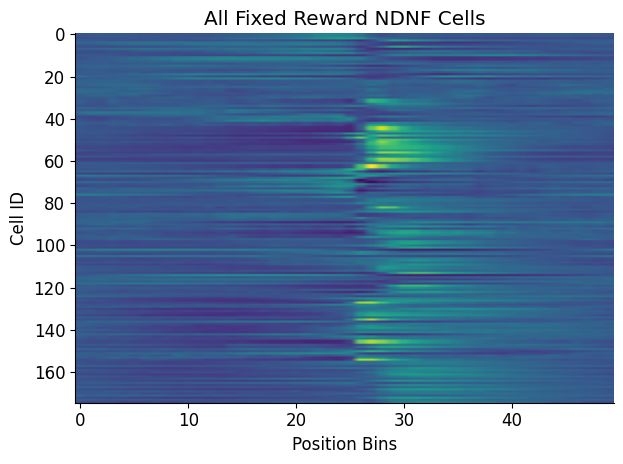

In [48]:
ta_list = []
ndnf_new_list = []
for animal in fixed_residual_activity_dict_NDNF_newest:
    for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
        ta_list.append(np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1))

ta_array = np.array(ta_list)
plt.imshow(ta_array, aspect='auto')
plt.xlabel("Position Bins")
plt.ylabel("Cell ID")
plt.title("All Fixed Reward NDNF Cells")
plt.tight_layout()
plt.show()

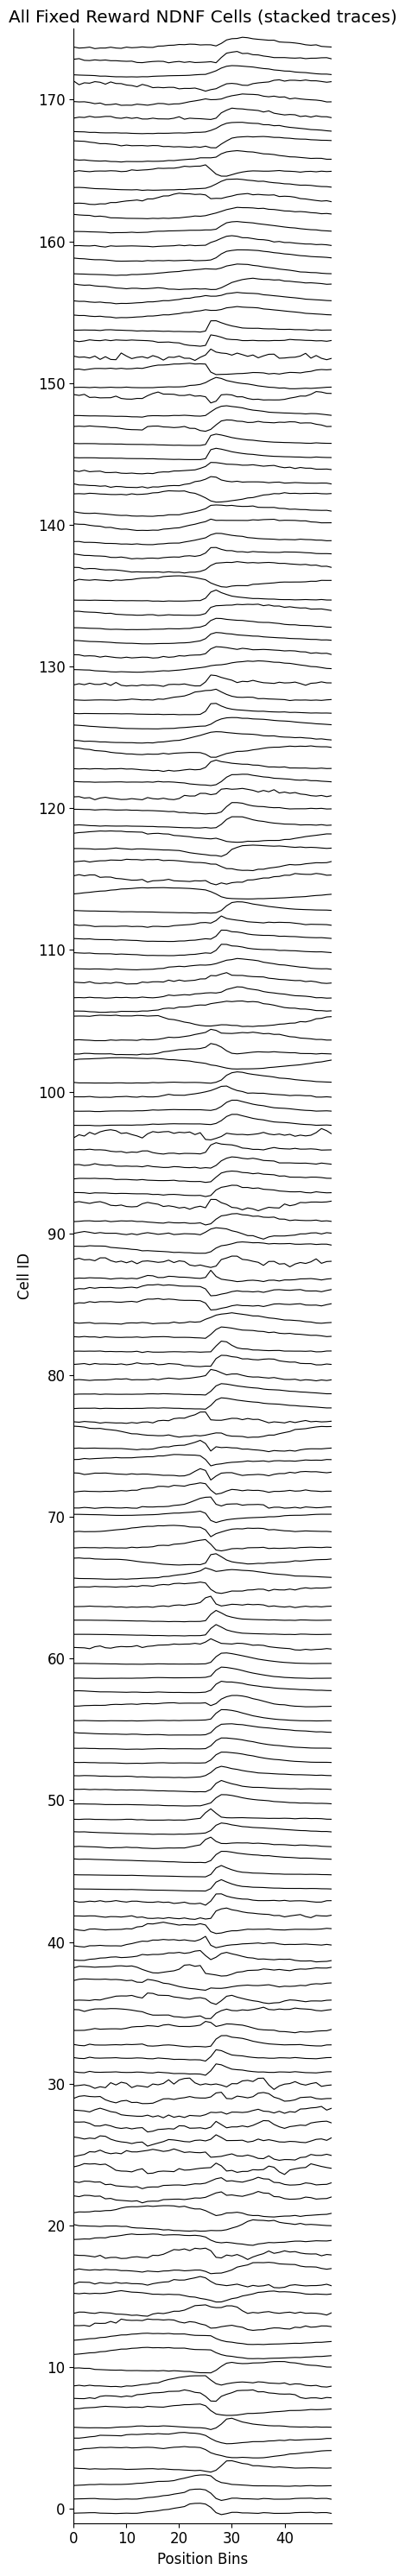

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def plot_stacked_cell_traces(
    ta_array,                # shape: (n_cells, n_pos)
    ax=None,
    scale="minmax",          # "minmax", "zscore", or None (raw)
    amp=1,                 # vertical amplitude of each waveform
    color="k",               # a single color or array-like of colors len=n_cells
    yticks_step=10,          # show every Nth cell on y-axis
    xlabel="Position Bins",
    title="All Fixed Reward NDNF Cells (stacked traces)",
    cue_bin=None             # e.g., 10 to draw a vertical cue line
):
    """
    Plots each row of ta_array as a line, vertically offset by its cell index.
    """
    n_cells, n_pos = ta_array.shape
    x = np.arange(n_pos)

    # scale each trace to comparable amplitude
    traces = ta_array.astype(float).copy()
    if scale == "minmax":
        # scale each row to [-0.5, 0.5] then multiply by amp*2
        rmin = np.nanmin(traces, axis=1, keepdims=True)
        rmax = np.nanmax(traces, axis=1, keepdims=True)
        denom = np.where((rmax - rmin) == 0, 1.0, (rmax - rmin))
        traces = ((traces - rmin) / denom) - 0.5
        traces *= (amp * 2.0)
    elif scale == "zscore":
        mu = np.nanmean(traces, axis=1, keepdims=True)
        sd = np.nanstd(traces, axis=1, keepdims=True)
        traces = (traces - mu) / np.where(sd == 0, 1.0, sd)
        # squash to desired vertical amplitude
        # (robust: tanh to limit outliers, then scale)
        traces = np.tanh(traces) * amp
    else:
        # raw, but clipped to ±amp to avoid overlaps
        rng = np.nanmax(np.abs(traces), axis=1, keepdims=True)
        rng = np.where(rng == 0, 1.0, rng)
        traces = traces / rng * amp

    # build segments for a LineCollection
    # y for cell i is traces[i] + i
    segs = []
    for i in range(n_cells):
        y = traces[i] + i
        segs.append(np.column_stack([x, y]))

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    lc = LineCollection(segs, colors=color, linewidths=0.8)
    ax.add_collection(lc)

    # axes cosmetics
    ax.set_xlim(0, n_pos - 1)
    ax.set_ylim(-1, n_cells)  # a bit of headroom at the top
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cell ID")
    ax.set_title(title)

    # y ticks every yticks_step
    ax.set_yticks(np.arange(0, n_cells, yticks_step))

    if cue_bin is not None:
        ax.axvline(cue_bin, linestyle="--")

    # tighten layout if we created the axes
    if ax is not None and hasattr(ax, "figure"):
        ax.figure.tight_layout()

    return ax


fig, ax = plt.subplots(figsize=(4,30))
plot_stacked_cell_traces(
    ta_array,
    ax=ax,
    scale="minmax",      # try "zscore" if you prefer
    amp=0.4,
    color="k",
    yticks_step=10,
    title="All Fixed Reward NDNF Cells (stacked traces)",
)
plt.show()


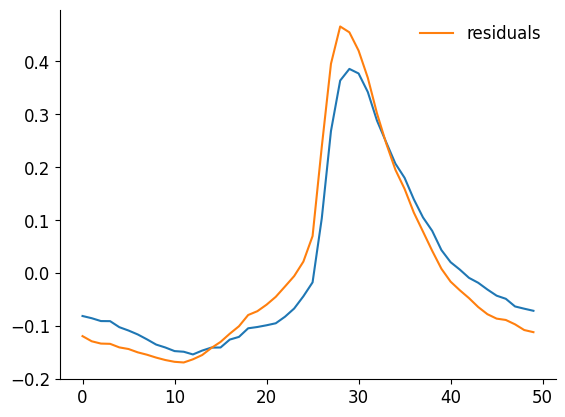

In [33]:
ndnf_new_list = []
for animal in fixed_residual_activity_dict_NDNF_newest:
    for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
        ndnf_new_list.append(np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1))

ndnf_new_array = np.array(ndnf_new_list)

mean_ndnf_new_array = np.mean(ndnf_new_array, axis=0)


ndnf_new_list_r = []
for animal in fixed_activity_dict_NDNF_newest:
    for cell in fixed_activity_dict_NDNF_newest[animal]:
        ndnf_new_list_r.append(np.mean(fixed_activity_dict_NDNF_newest[animal][cell], axis=1))

ndnf_new_array_r = np.array(ndnf_new_list_r)

mean_ndnf_new_arrayr = np.mean(ndnf_new_array_r, axis=0)

plt.plot(mean_ndnf_new_array)
plt.plot(mean_ndnf_new_arrayr, label='residuals')
plt.legend()



In [3]:
filepath="/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E0A1B1_251107.mat"
with h5py.File(filepath, 'r') as f:
    print(f.keys())

<KeysViewHDF5 ['#refs#', 'animals', 'sessions']>


In [111]:
mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/ndnf_cell_types/Newest_NDNF_model_ranks20_contigkmeans_00x_fixed'
cell_NDNF_model_ranks20_contig_x00_final_fixed = get_model_data_per_cell(mse_dir)

NDNF_fixed_model_dict = {}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_final_fixed):
    NDNF_fixed_model_dict_cell = {}
    for idt, cell in enumerate(cell_NDNF_model_ranks20_contig_x00_final_fixed[animal]):
        just_model = cell_NDNF_model_ranks20_contig_x00_final_fixed[animal][cell][0]
        NDNF_fixed_model_dict_cell[idt] = just_model
    NDNF_fixed_model_dict[idx] = NDNF_fixed_model_dict_cell





In [159]:
mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/ndnf_cell_types/Newest_NDNF_model_ranks20_contigkmeans_00x_cue_track'
cell_NDNF_model_ranks20_contig_x00_final_cued = get_model_data_per_cell(mse_dir)

NDNF_cued_model_dict = {}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_final_cued):
    NDNF_cued_model_dict_cell = {}
    for idt, cell in enumerate(cell_NDNF_model_ranks20_contig_x00_final_cued[animal]):
        just_model = cell_NDNF_model_ranks20_contig_x00_final_cued[animal][cell][0]
        NDNF_cued_model_dict_cell[idt] = just_model
    NDNF_cued_model_dict[idx] = NDNF_cued_model_dict_cell




In [ ]:

def get_real_animal_tensor(residual_activity_dict_SST, animal_num=1):
    real_animal_activity = residual_activity_dict_SST[f'animal_{animal_num+29}']
    real_animal_data_list = []
    for neuron in real_animal_activity:
        cell_activity = real_animal_activity[neuron]
        real_animal_data_list.append(cell_activity)
    animal_tensor = np.array(real_animal_data_list)
    animal_tensor = animal_tensor.transpose(2, 0, 1)
    
    return animal_tensor

from scipy.spatial.distance import cdist

def enforce_min_cluster_size(labels, X, min_trials=3, max_passes=2, verbose=False):
    """
    Post-process k-means labels to ensure each cluster has at least min_trials samples.
    Reassigns members of small clusters to the nearest 'big' cluster by Euclidean distance in X.
    Optionally iterates (max_passes) because reassignments change cluster sizes.

    Parameters
    ----------
    labels : (n_samples,) int array
    X      : (n_samples, n_feats) array used for clustering (here: f1)
    min_trials : int, minimum cluster size
    max_passes : int, do a couple passes to stabilize
    verbose    : bool

    Returns
    -------
    new_labels : (n_samples,) int array with no small clusters
    kept_map   : dict old_label -> new_label (only for surviving clusters)
    """
    labels = np.asarray(labels).copy()
    for _ in range(max_passes):
        # sizes per label
        uniq, counts = np.unique(labels, return_counts=True)
        small = set(uniq[counts < min_trials])
        big   = [u for u,c in zip(uniq, counts) if c >= min_trials]

        if verbose:
            print(f"[min-size pass] big={big}, small={sorted(small)}")

        if not small:
            break

        # centroids for current labels
        centroids = {}
        for u in uniq:
            centroids[u] = X[labels == u].mean(axis=0)

        # reassign every sample from small clusters to nearest big centroid
        big_centroid_mat = np.vstack([centroids[b] for b in big]) if big else None
        for u in list(small):
            mask = (labels == u)
            if not big:
                # corner case: everything is small; just put all in one cluster
                labels[mask] = 0
                continue
            d = cdist(X[mask], big_centroid_mat)  # (n_small, n_big)
            nn = d.argmin(axis=1)
            labels[mask] = np.array(big, dtype=int)[nn]

        # continue to next pass; sizes will be updated in next loop

    # compress labels to 0..K'-1
    uniq = np.unique(labels)
    remap = {u:i for i,u in enumerate(uniq)}
    new_labels = np.array([remap[u] for u in labels], dtype=int)

    kept_map = {u: remap[u] for u in uniq}
    return new_labels, kept_map


def get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(EC_model_dict_00x_cell, residual_activity_dict_SST, max_clusters=12, display=True, use_changepoint=False):

    MSE_mean_clusters = []
    MSE_sem_clusters = []
    X_f1_dict = {}
    labels_dict = {}
    indices_for_cluster_number_dict = {}
    TCA_reconstructions_dict = {}
    Recon_by_cluster_av_dict = {}
    cluster_trial_mean_dict = {}

    for clusters_chosen in range(2, max_clusters):

        animal_MSE_list = []
        animal_X_f1_dict = {}
        animal_labels_dict = {}
        animal_indices_for_cluster_number = {}
        animal_TCA_reconstructions_dict = {}
        animal_Recon_by_cluster_av_dict = {}
        animal_cluster_trial_mean_dict = {}

        for animal_id, animal in enumerate(EC_model_dict_00x_cell):

            animal_id = animal_id +1

            cell_MSE_list = []
            cell_X_f1_dict = {}
            cell_labels_dict = {}
            cell_indices_for_cluster_number = {}
            cell_TCA_reconstructions_dict = {}
            cell_Recon_by_cluster_av_dict = {}
            cell_cluster_trial_mean_dict = {}

            for cell_id, cell in enumerate(EC_model_dict_00x_cell[animal]):

                model = EC_model_dict_00x_cell[animal][cell]

            # for model in EC_model_dict_00x_cell[animal]:
                reconstruction_cell = model.construct().numpy(force=True)
                cell_TCA_reconstructions_dict[f"cell_{cell_id}"] = reconstruction_cell


                f = model.vectors[2][1].detach()
                f1 = f.permute(2, 0, 1)  # [5, 40, 212]

                f1 = f1.reshape(-1, f1.shape[-1]).T  # [200, 212]
                
                if use_changepoint:
                    # f1_model = f1.f1(n_components=3, random_state=0)
                    # X_f1 = f1_model.fit_transform(f1)  #(trials,3)

                    algo = rpt.Binseg(model="l2", min_size=5).fit(f1)
                    bkps = algo.predict(n_bkps=clusters_chosen-1)

                    labels = np.zeros(f1.shape[0], dtype=int)
                    start = 0
                    for cluster_id, end in enumerate(bkps):
                        labels[start:end] = cluster_id
                        start = end

                else:
                    print(f"f1.shape {f1.shape}")
                    kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
                    labels = kmeans.fit_predict(f1)

                min_trials = 3  # your criterion
                labels, kept_map = enforce_min_cluster_size(labels, f1, min_trials=min_trials, max_passes=2, verbose=False)


                cell_X_f1_dict[f"cell_{cell_id}"] = f1
                cell_labels_dict[f"cell_{cell_id}"] = labels

#                 mean_cluster_trials = []
                animal_tensor = get_real_animal_tensor(residual_activity_dict_SST, animal_id)
                neuron_activity = animal_tensor[:,cell_id,:]

                valid_cluster_mean_trials_list = []
                valid_cluster_indices = []
                for n in range(clusters_chosen):
                    trial_indices = np.where(labels == n)[0]

                    if len(trial_indices) > 2:

                        cluster_trials = reconstruction_cell[trial_indices, 0, :]  # shape (num_trials, time)


                        mean_cluster = cluster_trials.mean(axis=0)
                        valid_cluster_mean_trials_list.append(mean_cluster)

                        valid_cluster_indices.append((n, trial_indices))

                    else:
                        print(f"Skipping cluster {n} (only {len(trial_indices)} trials)")
                cell_cluster_trial_mean_dict[f"cell_{cell_id}"] = valid_cluster_mean_trials_list
                cluster_trial_indices = {n: np.where(labels == n)[0] for n in range(clusters_chosen)}
                cell_indices_for_cluster_number[f"cell_{cell_id}"] = cluster_trial_indices


                empty_cell = np.zeros(neuron_activity.shape)

                for i, (n, trials) in enumerate(valid_cluster_indices):
                    empty_cell[trials,:] = valid_cluster_mean_trials_list[i]
                cell_Recon_by_cluster_av_dict[f"cell_{cell_id}"] = empty_cell

                neuron_MSE = np.mean(np.square(neuron_activity - empty_cell))

                cell_MSE_list.append(neuron_MSE)

            mean_cell_MSE = np.mean(cell_MSE_list)
            animal_MSE_list.append(mean_cell_MSE)

            animal_X_f1_dict[animal] = cell_X_f1_dict
            animal_labels_dict[animal] = cell_labels_dict
            animal_indices_for_cluster_number[animal] = cell_indices_for_cluster_number
            animal_TCA_reconstructions_dict[animal] = cell_TCA_reconstructions_dict
            animal_Recon_by_cluster_av_dict[animal] = cell_Recon_by_cluster_av_dict
            animal_cluster_trial_mean_dict[animal] = cell_cluster_trial_mean_dict

            
        animal_MSE_array = np.array(animal_MSE_list)
        print(f"animal_MSE_array.shape {animal_MSE_array.shape}")
        
        MSE_mean_clusters.append(np.mean(animal_MSE_array))
        MSE_sem_clusters.append(sem(animal_MSE_array))
        
        X_f1_dict[f"clusters_{clusters_chosen}"] = animal_X_f1_dict
        labels_dict[f"clusters_{clusters_chosen}"] = animal_labels_dict
        indices_for_cluster_number_dict[f"clusters_{clusters_chosen}"] = animal_indices_for_cluster_number
        TCA_reconstructions_dict[f"clusters_{clusters_chosen}"] = animal_TCA_reconstructions_dict
        Recon_by_cluster_av_dict[f"clusters_{clusters_chosen}"] = animal_Recon_by_cluster_av_dict
        cluster_trial_mean_dict[f"clusters_{clusters_chosen}"] = animal_cluster_trial_mean_dict
        
        
    print(f"len(MSE_mean_clusters) {len(MSE_mean_clusters)}")


    internals_dict = {
        
        "X_f1_dict" : X_f1_dict,
        "labels_dict" : labels_dict,
        "indices_for_cluster_number_dict" : indices_for_cluster_number_dict,
        "TCA_reconstructions_dict" : TCA_reconstructions_dict,
        "Recon_by_cluster_av_dict" : Recon_by_cluster_av_dict,
        "cluster_trial_mean_dict" : cluster_trial_mean_dict,
        "MSE_mean_clusters":MSE_mean_clusters}

    return MSE_mean_clusters, MSE_sem_clusters, internals_dict
                
    #return MSE_list, x_pca_list, labels_list, indices_for_cluster_number, Recon_by_cluster_av_list, TCA_reconstructions_list, cluster_trial_mean_list

# MSE_mean_clusters_NDNF_cell_00x_f1_kmeans, MSE_sem_clusters_NDNF_cell_00x_f1_kmeans, internals_dict_NDNF_cell_00x_f1_contig = get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(NDNF_fixed_model_dict, fixed_residual_activity_dict_NDNF_newest, max_clusters=8, display=False, use_changepoint=False)

In [146]:

MSE_mean_clusters_NDNF_cell_00x_f1_kmeans, MSE_sem_clusters_NDNF_cell_00x_f1_kmeans, internals_dict_NDNF_cell_00x_f1_regkmean_reassign = get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(NDNF_fixed_model_dict, fixed_residual_activity_dict_NDNF_newest, max_clusters=8, display=False, use_changepoint=False)

model SliceTCA(
  (vectors): ModuleList(
    (0): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x217]
        (1): Parameter containing: [torch.float32 of size 0x1x50]
    )
    (1): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x1]
        (1): Parameter containing: [torch.float32 of size 0x217x50]
    )
    (2): ParameterList(
        (0): Parameter containing: [torch.float32 of size 20x50]
        (1): Parameter containing: [torch.float32 of size 20x217x1]
    )
  )
)
f1.shape torch.Size([217, 20])
model SliceTCA(
  (vectors): ModuleList(
    (0): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x217]
        (1): Parameter containing: [torch.float32 of size 0x1x50]
    )
    (1): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x1]
        (1): Parameter containing: [torch.float32 of size 0x217x50]
    )
    (2): ParameterList(
        (0): Parameter containing: [torch.float32 

In [158]:

MSE_mean_clusters_NDNF_cell_00x_f1_kmeans, MSE_sem_clusters_NDNF_cell_00x_f1_kmeans, internals_dict_NDNF_cell_00x_f1_regkmean_reassign_cued = get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(NDNF_cued_model_dict, cued_residual_activity_dict_NDNF_newest, max_clusters=8, display=False, use_changepoint=False)

f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([232, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([201, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape torch.Size([245, 20])
f1.shape

In [160]:

MSE_mean_clusters_NDNF_cell_00x_f1_kmeans, MSE_sem_clusters_NDNF_cell_00x_f1_kmeans, internals_dict_NDNF_cell_00x_f1_changepoint_cued = get_per_cell_sliceTCA_reconstruction_f1_regkmean_00x(NDNF_cued_model_dict, cued_residual_activity_dict_NDNF_newest, max_clusters=8, display=False, use_changepoint=True)

animal_MSE_array.shape (13,)
animal_MSE_array.shape (13,)
animal_MSE_array.shape (13,)
animal_MSE_array.shape (13,)
animal_MSE_array.shape (13,)
animal_MSE_array.shape (13,)
len(MSE_mean_clusters) 6


In [141]:
import re

def repackage_labels_to_rank_animal_cell_model(
    internals_dict,
    model_lookup,                  # <-- REQUIRED: same [animal][cell] structure holding your models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",
):
    """
    Build:
      out[rank_key][animal][cell] = [ model, { f'cell_{cell}': { 'labels_dict': {...} } } ]

    Where the labels_dict aggregates all cluster sizes from internals_dict['labels_dict'].
    """

    def _get_model(animal, cell_idx):
        """
        Try several key styles to fetch the model from model_lookup.
        """
        if animal not in model_lookup:
            return None
        # direct int key
        if cell_idx in model_lookup[animal]:
            return model_lookup[animal][cell_idx]
        # 'cell_<idx>' key
        ck = f"cell_{cell_idx}"
        if ck in model_lookup[animal]:
            return model_lookup[animal][ck]
        # fallback: if keys are strings of ints
        if str(cell_idx) in model_lookup[animal]:
            return model_lookup[animal][str(cell_idx)]
        # if model_lookup[animal] is a list/tuple indexed by int
        try:
            return model_lookup[animal][cell_idx]
        except Exception:
            return None

    labels_root = internals_dict.get("labels_dict", {})
    out = {rank_key: {}}

    # We'll accumulate per (animal, cell) and attach the model once per cell
    # Structure we are building for the second list element:
    #   {'cell_<idx>': {'labels_dict': {'clusters_chosen_<k>': labels_arr, ...}}}
    acc = {}  # (animal, cell_idx) -> {'cell_<idx>': {'labels_dict': {...}}}

    for clusters_key, animal_map in labels_root.items():
        # parse k from "clusters_2"
        m = re.match(rf"{re.escape(clusters_src_prefix)}(\d+)$", clusters_key)
        if not m:
            continue
        k = int(m.group(1))
        dst_key = f"{clusters_dst_prefix}{k}"

        for animal, cells_dict in animal_map.items():
            out[rank_key].setdefault(animal, {})
            for cell_key, labels_arr in cells_dict.items():
                mcell = re.match(r"cell_(\d+)$", str(cell_key))
                cell_idx = int(mcell.group(1)) if mcell else (int(cell_key) if str(cell_key).isdigit() else cell_key)
                acc_key = (animal, cell_idx)

                # init the labels container for this cell if needed
                if acc_key not in acc:
                    acc[acc_key] = {f"cell_{cell_idx}": {"labels_dict": {}}}

                acc[acc_key][f"cell_{cell_idx}"]["labels_dict"][dst_key] = labels_arr

    # Now assemble the final structure: [model, labels_dict_struct]
    for (animal, cell_idx), labels_struct in acc.items():
        model_obj = _get_model(animal, cell_idx)
        out[rank_key].setdefault(animal, {})
        out[rank_key][animal][cell_idx] = [model_obj, labels_struct]

    return out


In [149]:
# len(fixed_contig_dict_final_x00[20][0][0])

fixed_kmean_dict_final_x00 = repackage_labels_to_rank_animal_cell_model(
    internals_dict_NDNF_cell_00x_f1_regkmean_reassign,
    model_lookup=NDNF_fixed_model_dict,   # <- your per-animal, per-cell models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",)


In [148]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_contig_models_NDNF.pkl', 'wb') as f:
    pickle.dump(fixed_contig_dict_final_x00, f)

In [150]:
with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_fixed_reassign_models_NDNF.pkl', 'wb') as f:
    pickle.dump(fixed_kmean_dict_final_x00, f)

In [161]:
fixed_kmean_dict_final_x00 = repackage_labels_to_rank_animal_cell_model(
    internals_dict_NDNF_cell_00x_f1_regkmean_reassign_cued,
    model_lookup=NDNF_cued_model_dict,   # <- your per-animal, per-cell models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",)

with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_cued_reassign_models_NDNF.pkl', 'wb') as f:
    pickle.dump(fixed_kmean_dict_final_x00, f)


In [162]:
fixed_contig_dict_final_x00 = repackage_labels_to_rank_animal_cell_model(
    internals_dict_NDNF_cell_00x_f1_changepoint_cued,
    model_lookup=NDNF_cued_model_dict,   # <- your per-animal, per-cell models
    rank_key=20,
    clusters_src_prefix="clusters_",
    clusters_dst_prefix="clusters_chosen_",)

with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/all_new_cued_contig_models_NDNF.pkl', 'wb') as f:
    pickle.dump(fixed_contig_dict_final_x00, f)


In [128]:

def preprocess_animal(NDNF_fixed_model_dict, residual_activity_dict, num_clusters=8, reassign_clusters=False, x00=True, umap=True, contiguous=True, ranks=20):
    # tensor_list_by_animal_all_SST = []
    # for animal in residual_activity_dict:
    #     neural_data = ut.get_animal_neural_tensor(residual_activity_dict, animal=animal)
    #     neural_data_tensor = torch.tensor(neural_data)
    #     # Normalize per cell
    #     for i in range(neural_data_tensor.shape[1]):
    #         cell = neural_data_tensor[:, i, :]
    #         min_val = cell.min()
    #         max_val = cell.max()
    #         neural_data_tensor[:, i, :] = (cell - min_val) / (max_val - min_val + 1e-8)
    #     tensor_list_by_animal_all_SST.append(neural_data_tensor)


    internals_per_animal_dict_EC_animal_x00_regkmean = {}
    
    for idx, animal in enumerate(residual_activity_dict):
        internals_per_animal_dict_EC_animal_x00_regkmean_cell = {}
        for idt, cell in enumerate(residual_activity_dict[animal]):

            cell_data = residual_activity_dict_NDNF_newest[animal][cell].T
            cell_data = ((cell_data-np.min(cell_data)) / np.max(cell_data) - np.min(cell_data))
            cell_data_3d = np.expand_dims(cell_data, axis=1)
            cell_data_3d = torch.from_numpy(cell_data_3d)
            cell_model = NDNF_fixed_model_dict[idx][idt]


    # internals_per_animal_dict_EC_animal_x00_regkmean = {}
    # for animal in animal_EC_model_ranks20_contig_x00[ranks]:
    #     animal_model = animal_EC_model_ranks20_contig_x00[ranks][animal][0]
        # tensor_for_animal = tensor_list_by_animal_all_SST[animal]
            internals_dict = get_animal_model_reconstruction_dict_mod(cell_model, cell_data_3d, max_clusters=num_clusters, display=False, reassign_small_clusters=reassign_clusters, x00=x00, use_umap=umap, use_breakpoints=contiguous)

            internals_per_animal_dict_EC_animal_x00_regkmean_cell[idt] = internals_dict
        
        internals_per_animal_dict_EC_animal_x00_regkmean[idx] = internals_per_animal_dict_EC_animal_x00_regkmean_cell

    return internals_per_animal_dict_EC_animal_x00_regkmean


def get_animal_model_reconstruction_dict_mod(animal_model, tensor_for_animal, max_clusters=12, display=False, reassign_small_clusters=True, x00=True, use_umap=False, use_breakpoints=False):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    per_cell_internals_dict = {}
    reconstruction_full_animal = animal_model.construct().numpy(force=True)

    if x00:
        w1 = animal_model.vectors[0][0].detach().numpy()
        X = np.abs(w1.T)
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(X)
    else:
        f = animal_model.vectors[2][1].detach()
        f1 = f.permute(1, 0, 2).reshape(f.shape[1], -1)
        f1 = torch.abs(f1).cpu().numpy()
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(f1)

    cluster_labels_dict = {}
    cluster_pca_dict = {}
    cluster_centroids_dict = {}

    for clusters_chosen in range(1, max_clusters):
        if use_breakpoints:
            print(f"Using breakpoint clustering (clusters = {clusters_chosen})")
            model_input = X_umap if use_umap else (X if x00 else f1)
            n_bkps = clusters_chosen - 1
            algo = rpt.Binseg(model="l2", min_size=3).fit(model_input)
            try:
                bkps = algo.predict(n_bkps=n_bkps)
            except rpt.exceptions.BadSegmentationParameters:
                print("  Skipping due to bad breakpoint config")
                continue

            labels = np.zeros(model_input.shape[0], dtype=int)
            start = 0
            for cluster_id, end in enumerate(bkps):
                labels[start:end] = cluster_id
                start = end

            centroids = np.array([
                model_input[labels == i].mean(axis=0)
                for i in range(clusters_chosen)
            ])
            X_pca = PCA(n_components=3).fit_transform(model_input)

        else:
            kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
            model_input = X_umap if use_umap else (X if x00 else f1)
            labels = kmeans.fit_predict(model_input)

            centroids = kmeans.cluster_centers_
            if use_umap:
                X_pca = PCA(n_components=3).fit_transform(X_umap)
            else:
                X_pca = PCA(n_components=3).fit_transform(model_input)

        cluster_labels_dict[clusters_chosen] = labels
        cluster_centroids_dict[clusters_chosen] = centroids
        cluster_pca_dict[clusters_chosen] = X_pca

    for cell in range(reconstruction_full_animal.shape[1]):
        #     cell = 0
        print(f"Processing cell {cell}...")

        MSE_dict = {}
        x_pca_dict = {}
        labels_dict = {}
        indices_for_cluster_number = {}
        TCA_reconstructions_dict = {}
        Recon_by_cluster_av_dict = {}
        cluster_trial_mean_dict = {}

        reconstructed_cell = reconstruction_full_animal[:, cell, :]
        real_cell_activity = tensor_for_animal[:, cell, :].detach().numpy()

        for clusters_chosen in range(1, max_clusters):
            labels = cluster_labels_dict[clusters_chosen].copy()
            centroids = cluster_centroids_dict[clusters_chosen]
            X_pca = cluster_pca_dict[clusters_chosen]
            model_input = X_umap if use_umap else (X if x00 else f1)

            print(f"\nclusters_chosen = {clusters_chosen}")
            print("Before reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            if reassign_small_clusters:
                if use_umap:
                    model_input = X_umap
                    centroid_space = np.array([
                        model_input[labels == i].mean(axis=0)
                        for i in range(clusters_chosen)])
                else:
                    model_input = X if x00 else f1
                    centroid_space = centroids
                for cluster_id in range(clusters_chosen):
                    trial_indices = np.where(labels == cluster_id)[0]
                    if len(trial_indices) < 2:
                        print(f"  Reassigning cluster {cluster_id} (size={len(trial_indices)})...")
                        for idx in trial_indices:
                            trial = model_input[idx]
                            dists = cdist([trial], centroid_space)[0]
                            dists[cluster_id] = np.inf
                            new_cluster = np.argmin(dists)
                            labels[idx] = new_cluster

            print("After reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            x_pca_dict[f"clusters_chosen_{clusters_chosen}"] = X_pca
            labels_dict[f"clusters_chosen_{clusters_chosen}"] = labels

            valid_cluster_mean_trials_list = []
            valid_cluster_indices = []
            cluster_trial_indices = {}

            for n in range(clusters_chosen):
                trial_indices = np.where(labels == n)[0]
                cluster_trial_indices[n] = trial_indices
                if len(trial_indices) == 0:
                    continue
                cluster_trials = real_cell_activity[trial_indices, :]
                mean_cluster = cluster_trials.mean(axis=0)
                valid_cluster_mean_trials_list.append(mean_cluster)
                valid_cluster_indices.append((n, trial_indices))

            empty_cell = np.zeros_like(reconstructed_cell)
            for i, (n, trials) in enumerate(valid_cluster_indices):
                empty_cell[trials, :] = valid_cluster_mean_trials_list[i]

            key = f"clusters_chosen_{clusters_chosen}"
            MSE_dict[key] = np.mean((real_cell_activity - empty_cell) ** 2)
            Recon_by_cluster_av_dict[key] = empty_cell
            TCA_reconstructions_dict[key] = reconstructed_cell
            cluster_trial_mean_dict[key] = valid_cluster_mean_trials_list
            indices_for_cluster_number[key] = cluster_trial_indices

        per_cell_internals_dict[f"cell_{cell}"] = {
            "MSE_dict": MSE_dict,
            "x_pca_dict": x_pca_dict,
            "labels_dict": labels_dict,
            "indices_for_cluster_number": indices_for_cluster_number,
            "TCA_reconstructions_dict": TCA_reconstructions_dict,
            "Recon_by_cluster_av_dict": Recon_by_cluster_av_dict,
            "cluster_trial_mean_dict": cluster_trial_mean_dict,
        }

    return per_cell_internals_dict

testing_data = preprocess_animal(NDNF_fixed_model_dict, cued_residual_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=False, umap=False, contiguous=False, ranks=20)


Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 217 trials
After reassignment:
  Cluster 0: 217 trials


ValueError: operands could not be broadcast together with shapes (232,50) (217,50) 

In [29]:
from comparing_slice_TCA_methods import *

(175, 50, 51)

In [62]:

def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, data_truncated_array_EC, data_to_corr=None):

    r_list_vel = []
    vel_per_animal = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:data_truncated_array_EC.shape[2]]
            vel_per_animal.append(vel)
            data = fixed_activity_dict_NDNF_newest[animal][cell][:,:data_truncated_array_EC.shape[2]]
            r, _ = pearsonr(vel.flatten(), data.flatten())
            r_list_vel.append(r)

    array_data = np.array(vel_per_animal)
    r_dict_vel = {"r_list":r_list_vel,
                  "array_data":array_data}

    return r_dict_vel

data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)

r_dict_vel = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks = get_r_list(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")
            

r_dict_vel_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Velocity")
r_dict_licks_resid = get_r_list(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, data_truncated_array_NDNF, data_to_corr="Licks")

AttributeError: 'tuple' object has no attribute 'shape'

In [1]:
data_truncated_array_NDNF = get_truncated_to_min_data_array(fixed_residual_activity_dict_NDNF_newest)
data_truncated_array_NDNF.shape

NameError: name 'get_truncated_to_min_data_array' is not defined

In [35]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl"

with open (save_path, 'rb') as f:
    model_and_mse_dict_NDNF = pickle.load(f)
    print(save_path)

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/pickle_every_slice_type_NDNF.pkl


In [47]:
############################# new data that is z scored and only trials removed are ones with nan in activity data ##################

filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/NDNF_E0A1B1_251107.mat'

use_final=True
with h5py.File(filepath, 'r') as f:
    if use_final:
        animal_group = f['animals']
    else:
        animal_group = f['animal']

    
    R_refs = animal_group['R'][:]

    shiftR_refs = animal_group['ShiftR'][:]

    animal_clean_dict_activity = {}

    for animal_idx in range(len(shiftR_refs)):
        delta_f = np.array(f[shiftR_refs[animal_idx][0]])
        nan_trials = np.any(np.isnan(delta_f), axis=(0, 2))
        delta_f_clean = delta_f[:, ~nan_trials, :]

        cell_dict = {}

        for cell in range(delta_f_clean.shape[0]):
            
            cell_data = delta_f_clean[cell,:,:].T

            delta_f_clean_z = (cell_data - np.mean(cell_data)) / np.std(cell_data)

            cell_dict[f"cell_{cell+1}"] = delta_f_clean_z

        animal_clean_dict_activity[f"animal_{animal_idx+1}"] = cell_dict

        

clean_fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(animal_clean_dict_activity):
    if 14 < idx < 29:
        clean_fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = animal_clean_dict_activity[animal]



torch.Size([86, 175, 50])


  0%|          | 0/4000 [00:00<?, ?it/s]

Loss: 0.4752809361820032 : 100%|██████████| 4000/4000 [04:39<00:00, 14.30it/s] 


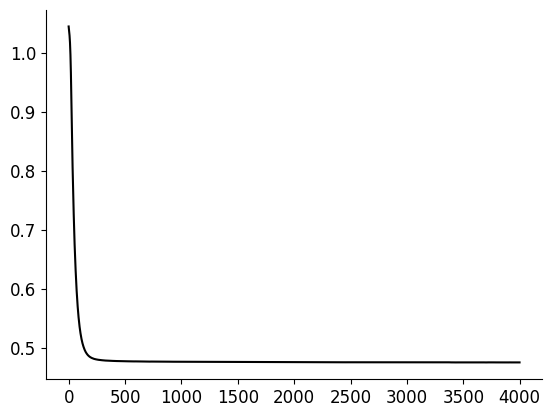

In [56]:
def get_the_tca_model(fixed_residual_activity_dict, components=None):
    data_truncated_array, min_val = get_truncated_to_min_data_array(fixed_residual_activity_dict)
    example_cell_tensor = torch.from_numpy(data_truncated_array)
    example_cell_tensor = example_cell_tensor.permute(2,0,1)

    print(example_cell_tensor.shape)
        
    components, model_20 = slicetca.decompose(example_cell_tensor,
                                                number_components=components, # (trials, neurons, time bins)
                                                positive=False,learning_rate=1*10**-2, min_std=10**-5, max_iter=4000, iter_std=1000,seed=0)

    plt.plot(model_20.losses, color='k')
    plt.show()

    return model_20, example_cell_tensor

model_20_raw_new_activity, example_cell_tensor = get_the_tca_model(clean_fixed_activity_dict_NDNF_newest, components=(0,20,0))


In [63]:
example_cell_tensor.shape

torch.Size([86, 175, 50])

In [67]:
from sklearn.preprocessing import StandardScaler


def plot_reconstructions(labels_list, fixed_activity_dict_NDNF_newest, prefix="", plot=False):


    synthetic_mean_array = {}
    means_dict_cluster= {}
    for num_clusters in labels_list:
    # for num_clusters in range(len(labels_list)):
        data_truncated_array_NDNF, _ = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
        labels = labels_list[num_clusters]
        uniq = np.unique(labels)
        real_data_mean_array = np.empty(data_truncated_array_NDNF.shape)
        mean_data_dict = {}

        r_vel_dict_per_clust = {}
        r_lick_dict_per_clust = {}

        cell_ids_per_cluster_dict = {}

        vel_data_sliced_dict = {}
        lick_data_sliced_dict = {}

        # vel_array = r_dict_vel["array_data"]
        # lick_array = r_dict_licks["array_data"]

        labels_loc_dict = {}

        mean_data_list = []
        fraction_cells_list = []
        for i in uniq:
            labels_loc = np.where(labels==i)[0]
            cell_ids_per_cluster_dict[i] = labels_loc
            fraction_cells = (len(labels_loc) / data_truncated_array_NDNF.shape[0])*100
            fraction_cells_list.append(fraction_cells)
            real_data_array_sliced = data_truncated_array_NDNF[labels_loc,:,:]
            mean_real_data_array_sliced = np.mean(real_data_array_sliced, axis=0)
            mean_data_list.append(mean_real_data_array_sliced)
            real_data_mean_array[labels_loc,:,:] = mean_real_data_array_sliced

            labels_loc_dict[i] = labels_loc
            
            # r_list_vel = np.array(r_dict_vel["r_list"])

            # r_list_licks = np.array(r_dict_licks["r_list"])

            

            # vel_data_sliced_dict[i] = vel_array[labels_loc,:,:]

            # lick_data_sliced_dict[i] = lick_array[labels_loc,:,:]

            # r_vel_dict_per_clust[i] = r_list_vel[labels_loc]
            # r_lick_dict_per_clust[i] = r_list_licks[labels_loc]



        MSE_reco_vs_real = np.mean(np.square(data_truncated_array_NDNF-real_data_mean_array))

        mean_data_dict = {"mean_data_list":mean_data_list,
                        "fraction_cells":fraction_cells_list,
                        "MSE_reco_vs_real":MSE_reco_vs_real,
                        # "r_vel_dict_per_clust":r_vel_dict_per_clust,
                        # "r_lick_dict_per_clust":r_lick_dict_per_clust,
                        "cell_ids_per_cluster_dict":cell_ids_per_cluster_dict,
                        # "vel_data_sliced_dict":vel_data_sliced_dict,
                        # "lick_data_sliced_dict":lick_data_sliced_dict,
                        "labels_loc_dict":labels_loc_dict}
        
        means_dict_cluster[num_clusters] = mean_data_dict
        synthetic_mean_array[num_clusters] = real_data_mean_array



    data_truncated_array_NDNF, _ = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)
    data_truncated_array_NDNF_ta = np.mean(data_truncated_array_NDNF, axis=2),
    if plot:
        fig, axs = plt.subplots(2,len(synthetic_mean_array), figsize=(30,8))
        plt.suptitle(f"Reconstructed vs Real Trial Averaged Data {prefix}")
        for num_clusters in synthetic_mean_array:
            reconstructed_data = synthetic_mean_array[num_clusters]
            reconstructed_data_ta = np.mean(reconstructed_data, axis=2)
            axs[0,num_clusters-1].imshow(reconstructed_data_ta, aspect='auto')
            axs[0,num_clusters-1].set_ylabel("Cell ID")
            axs[0,num_clusters-1].set_title(f"Reconstructed K={num_clusters}")
            axs[0,num_clusters-1].set_xlabel("Position Bin")
            axs[1,num_clusters-1].imshow(data_truncated_array_NDNF_ta, aspect='auto')
            axs[1,num_clusters-1].set_title("Real T.A. Data")
            axs[1,num_clusters-1].set_xlabel("Position Bin")
        plt.tight_layout()
        plt.show()

    return means_dict_cluster

# def get_r_list(fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, num_trials, data_to_corr=None):

#     r_list_vel = []
#     vel_per_animal = []
#     for animal in fixed_activity_dict_NDNF_newest:
#         for cell in fixed_activity_dict_NDNF_newest[animal]:
#             vel = factors_dict_NDNF_newest[animal][data_to_corr][:,:num_trials]
#             vel_per_animal.append(vel)
#             data = fixed_activity_dict_NDNF_newest[animal][cell][:,:num_trials]
#             r, _ = pearsonr(vel.flatten(), data.flatten())
#             r_list_vel.append(r)

#     array_data = np.array(vel_per_animal)
#     r_dict_vel = {"r_list":r_list_vel,
#                   "array_data":array_data}

#     return r_dict_vel



# r_dict_vel = get_r_list(clean_fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, example_cell_tensor.shape[0], data_to_corr=None)
# r_dict_licks = get_r_list(clean_fixed_activity_dict_NDNF_newest, factors_dict_NDNF_newest, example_cell_tensor.shape[0], data_to_corr=None)



def get_labels_all_different_Ks_single(model_20_NDNF_resid, which_vectors: int):

    w1 = model_20_NDNF_resid.vectors[which_vectors][0]
    f1 = model_20_NDNF_resid.vectors[which_vectors][1]
    F = f1.detach().cpu().numpy()   # (latents, cells, pos) = (20, 115, 50)
    W = w1.detach().cpu().numpy()   # (latents, trials) = (20, 100)

    print(f"F.shape {F.shape}  W.shape {W.shape}")

    # Build X so rows = cells (115)
    if which_vectors == 0:
        # Use latent×pos per cell, flattened: (115, 20*50)
        X = np.moveaxis(F, 1, 0)              # (cells=115, latents=20, pos=50)
        X = X.reshape(X.shape[0], -1)         # (115, 1000)
        print("X shape (latent×pos flat):", X.shape)

    elif which_vectors == 1:
        X = W.T  # (115, 20) mean over pos
        print("X shape (mean over pos):", X.shape)

    else:
        X = np.moveaxis(F, 2, 0)     # -> (cells=115, latents=20, trials=100)
        X = X.reshape(X.shape[0], -1)  # -> (115, 20*100) = (115, 2000)
        print(X.shape)  # (115, 2000)

    Xz = StandardScaler().fit_transform(X)
    labels_cells_dict_all_K = {K: KMeans(n_clusters=K, n_init=100, random_state=42).fit_predict(Xz) for K in range(1, 11)}
    return labels_cells_dict_all_K



labels_dict_raw_new = get_labels_all_different_Ks_single(model_20_raw_new_activity, which_vectors=1)
means_dict_raw_new = plot_reconstructions(labels_dict_raw_new, clean_fixed_activity_dict_NDNF_newest, prefix="NDNF Raw New")



# activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
# plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint")

F.shape (20, 86, 50)  W.shape (20, 175)
X shape (mean over pos): (175, 20)


In [73]:

def plot_cluster_traces_by_animal(
    means_dict_cluster,                 # output from plot_reconstructions (has cell_ids_per_cluster_dict)
    fixed_activity_dict_NDNF_newest,    # to recompute TA traces
    cells_per_animal_dict,              # {animal: [global_cell_ids...]}
    K, ncol=None,                                  # which K to plot
    ylim=(-1.1, 2.6), spacing=None,  
    title_prefix=""
):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[cid] = animal

    # --- get TA data (cells × pos) ---
    data, min_val = get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest)  # (cells, pos, trials)
    ta = data.mean(axis=2)                                                   # (cells, pos)
    n_cells, n_pos = ta.shape

    # --- clusters & subplot layout ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]      # {cluster_label: array(cell_ids)}
    uniq = sorted(clust_idx_dict.keys())
    label_to_col = {lab: j for j, lab in enumerate(uniq)}

    # --- color map per animal ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    fig, axs = plt.subplots(1, len(uniq), figsize=(4*len(uniq), 6), sharey=True)
    if len(uniq) == 1:
        axs = np.array([axs])

    for lab in uniq:
        ax = axs[label_to_col[lab]]
        idx = np.asarray(clust_idx_dict[lab])
        traces = ta[idx]                                   # (n_k, n_pos)

        # plot each cell trace colored by its animal
        for cid in idx:
            a = cell_to_animal.get(int(cid), "unknown")
            color = animal_to_color.get(a, (0.5,0.5,0.5,0.6))
            ax.plot(traces[np.where(idx==cid)[0][0], :], lw=1.0, alpha=0.7, color=color)

        # overlay mean ± SEM (neutral color)
        m = traces.mean(axis=0)
        s = sem(traces, axis=0) if traces.shape[0] > 1 else np.zeros_like(m)
        ax.plot(m, lw=2.0, color="k")
        ax.fill_between(np.arange(n_pos), m - s, m + s, alpha=0.15, color="k")

        ax.set_title(f"Cluster {lab} (n={len(idx)})")
        ax.set_xlabel("Position bins")
        ax.set_ylim(*ylim)
    axs[0].set_ylabel("Z-scored dF/F")
    fig.suptitle(f"{title_prefix} Traces colored by animal — K={K}", y=1.02, fontsize=12)

    # legend outside: one entry per animal
    handles = [plt.Line2D([0],[0], color=animal_to_color[a], lw=2) for a in animals]
    labels = [f"{a}" for a in animals]
    fig.legend(handles, labels, loc="lower center", ncol=ncol, frameon=False)
    fig.subplots_adjust(top=0.85, right=0.98, left=0.07, bottom=spacing)
    plt.show()


# # plot_cluster_traces_by_animal(means_dict_cluster_00x_raw,
# #                               activity_dict_EC,
# #                               cells_per_animal_dict,
# #                               K=2,ylim=(-0.7, 1.6), spacing=0.2, ncol=4,
# #                               title_prefix="EC 00x Raw")

# plot_cluster_traces_by_animal(means_dict_cluster_0x0_resid,
#                               residual_activity_dict_EC,
#                               cells_per_animal_dict,
#                               K=3, ylim=(-0.7, 1.6), spacing=0.2, 
#                               ncol=7, 
#                               title_prefix="EC 0x0 Residuals")



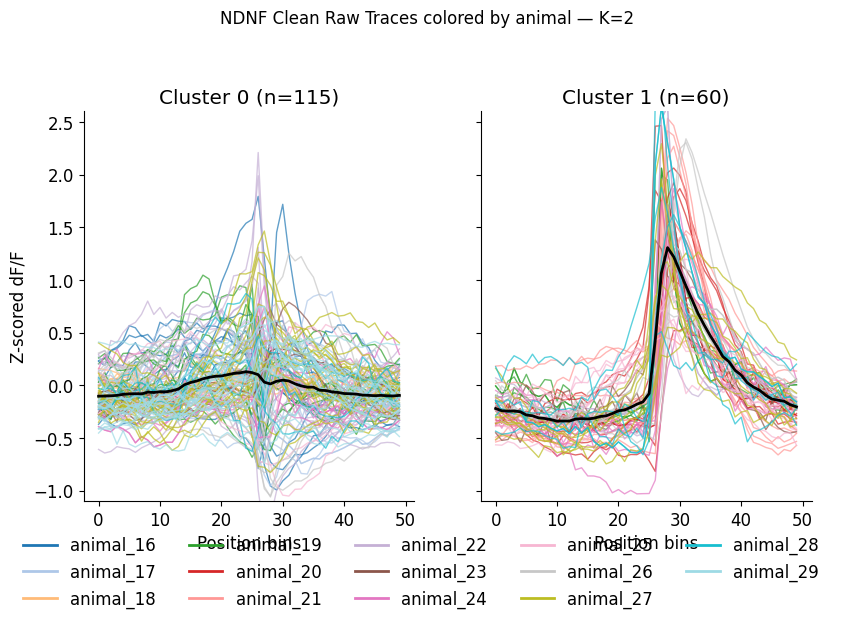

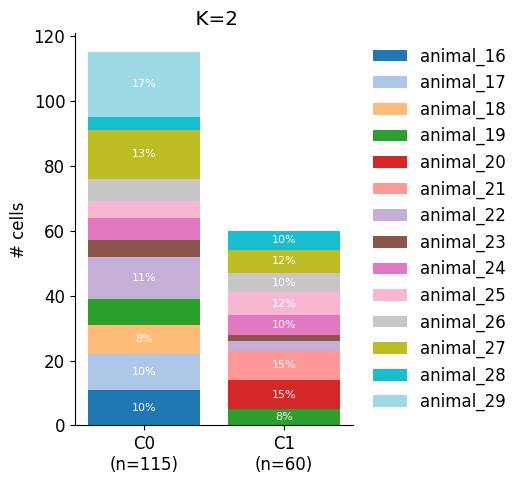

In [80]:
from comparing_slice_TCA_methods import get_cells_per_animal_dict

K=2

cells_per_animal_dict = get_cells_per_animal_dict(clean_fixed_activity_dict_NDNF_newest)
plot_cluster_traces_by_animal(means_dict_raw_new,
                              clean_fixed_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=K,
                              ncol=5, spacing=0.2,
                              title_prefix="NDNF Clean Raw")

plot_cluster_animal_composition_stacked(means_dict_raw_new, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=True)

In [ ]:
activity_early_array, activity_array_late = get_activity_cut_learn(cue_residual_activity_dict_NDNF_newest, cued_cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_cue_resid, activity_early_array, activity_array_late, K=2, title="Cued Track Residuals NDNF Clustered Changepoint")

NameError: name 'means_dict_cluster' is not defined

In [6]:


def preprocess_data2(filepath, normalize=True, new_NDNF=False, use_final=False):
    factors_dict = {}
    activity_dict = {}

    if new_NDNF:
        with h5py.File(filepath, 'r') as f:
            if use_final:
                animal_group = f['animals']
            else:
                animal_group = f['animal']
            shiftR_refs = animal_group['ShiftR'][:]
            shiftRunning_refs = animal_group['ShiftRunning'][:]
            shiftL_refs = animal_group['ShiftL'][:]
            shiftV_refs = animal_group['ShiftV'][:]

            for animal_idx in range(len(shiftR_refs)):
                delta_f = np.array(f[shiftR_refs[animal_idx][0]])
                delta_f = delta_f.swapaxes(0, 2)
                velocity = np.array(f[shiftRunning_refs[animal_idx][0]]).T
                lick_rate = np.array(f[shiftL_refs[animal_idx][0]]).T
                reward_loc = np.array(f[shiftV_refs[animal_idx][0]]).T

                if delta_f.shape[1] > 1:
                    delta_f = delta_f[:, 1:, :]  # remove duplicate neuron

                num_trials = min(delta_f.shape[1], velocity.shape[1], lick_rate.shape[1], reward_loc.shape[1])

                delta_f = delta_f[:, :num_trials, :]
                velocity = velocity[:, :num_trials]
                lick_rate = lick_rate[:, :num_trials]
                reward_loc = reward_loc[:, :num_trials]

                nan_trials = (
                        np.any(np.isnan(lick_rate), axis=0) |
                        np.any(np.isnan(reward_loc), axis=0) |
                        np.any(np.isnan(velocity), axis=0) |
                        np.any(np.isnan(delta_f), axis=(0, 2))
                )

                animal_key = f'animal_{animal_idx + 1}'
                factors_dict[animal_key] = {
                    "Licks": lick_rate[:, ~nan_trials],
                    "Reward_loc": reward_loc[:, ~nan_trials],
                    "Velocity": velocity[:, ~nan_trials]
                }

                if normalize:
                    for var in factors_dict[animal_key]:
                        factors_dict[animal_key][var] = ((factors_dict[animal_key][var] - np.min(factors_dict[animal_key][var])) /
                                                         (np.max(factors_dict[animal_key][var]) - np.min(factors_dict[animal_key][var])))

                activity_dict[animal_key] = {}
                for neuron_idx in range(delta_f.shape[2]):  # loop over neurons
                    neuron_activity = delta_f[:, :, neuron_idx]  # (trial, bin)
                    if np.all(np.isnan(neuron_activity)) or np.all(neuron_activity == 0):
                        continue

                    cleaned_activity = neuron_activity[:, ~nan_trials]
                    if normalize:
                        cleaned_activity = (cleaned_activity - np.mean(cleaned_activity)) / np.std(cleaned_activity)
                    neuron_key = f'cell_{neuron_idx + 1}'
                    activity_dict[animal_key][neuron_key] = cleaned_activity


    else:
        data_dict = mat73.loadmat(filepath)

        # Setup position variables
        num_spatial_bins = 10
        position_matrix = np.zeros((50, num_spatial_bins))
        bin_size = 50 // num_spatial_bins
        for i in range(num_spatial_bins):
            position_matrix[i * bin_size:(i + 1) * bin_size, i] = 1

        for animal_idx, (delta_f, velocity, lick_rate, reward_loc) in enumerate(
                zip(data_dict['animal']['ShiftR'], data_dict['animal']['ShiftRunning'], data_dict['animal']['ShiftLrate'], data_dict['animal']['ShiftV'])):

            num_trials = min(delta_f.shape[1], lick_rate.shape[1], reward_loc.shape[1], velocity.shape[1])
            delta_f = delta_f[:, :num_trials, :]
            velocity = velocity[:, :num_trials]
            lick_rate = lick_rate[:, :num_trials]
            reward_loc = reward_loc[:, :num_trials]

            nan_trials = (
                    np.any(np.isnan(lick_rate), axis=0) |
                    np.any(np.isnan(reward_loc), axis=0) |
                    np.any(np.isnan(velocity), axis=0) |
                    np.any(np.isnan(delta_f), axis=(0, 2)))

            animal_key = f'animal_{animal_idx + 1}'
            factors_dict[animal_key] = {
                "Licks": lick_rate[:, ~nan_trials],
                "Reward_loc": reward_loc[:, ~nan_trials],
                "Velocity": velocity[:, ~nan_trials]}

            # Add position info
            num_trials = factors_dict[animal_key]["Velocity"].shape[1]
            for bin_idx in range(num_spatial_bins):
                bin_key = f"Position_{bin_idx + 1}"
                factors_dict[animal_key][bin_key] = np.tile(position_matrix[:, bin_idx][:, np.newaxis], num_trials)

            if normalize:
                for var in factors_dict[animal_key]:
                    factors_dict[animal_key][var] = (
                            (factors_dict[animal_key][var] - np.min(factors_dict[animal_key][var])) /
                            (np.max(factors_dict[animal_key][var]) - np.min(factors_dict[animal_key][var])))

            activity_dict[animal_key] = {}
            for neuron_idx in range(delta_f.shape[2]):
                neuron_activity = delta_f[:, :, neuron_idx]
                if np.all(np.isnan(neuron_activity)) or np.all(neuron_activity == 0):
                    continue
                cleaned_activity = neuron_activity[:, ~nan_trials]
                if normalize:
                    cleaned_activity = (cleaned_activity - np.mean(cleaned_activity)) / np.std(cleaned_activity)
                neuron_key = f'cell_{neuron_idx + 1}'
                activity_dict[animal_key][neuron_key] = cleaned_activity

    return activity_dict, factors_dict


def load_data_regular(file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM", name="NDNFanalC", new_NDNF=True, use_final=False):
    file_path = file_path
    filename = name
    filepath = os.path.join(file_path, "datasets", filename + ".mat")

    activity_dict, factors_dict = preprocess_data2(filepath, normalize=True, new_NDNF=new_NDNF, use_final=use_final)

    filtered_factors_dict = subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"])

    GLM_params, double_predicted_activity_dict_NDNF_new = fit_GLM_population(filtered_factors_dict, activity_dict, quintile=None, regression='linear')
    double_residual_activity_dict_NDNF_new = get_residual_activity_dict(activity_dict, double_predicted_activity_dict_NDNF_new)

    return GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, double_residual_activity_dict_NDNF_new


def flatten_data(neuron_dict):
    flattened_data = {}
    for var in neuron_dict:
        flattened_data[var] = neuron_dict[var].flatten()
    return flattened_data

def fit_GLM(animal_factors_dict, neuron_activity, regression='linear', alphas=None):
    neuron_activity_flat = neuron_activity.flatten()
    flattened_data = flatten_data(animal_factors_dict)
    variable_names = [var for var in flattened_data]
    design_matrix_X = np.stack([flattened_data[var] for var in variable_names], axis=1)

    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    neuron_predicted_activity = model.predict(design_matrix_X)

    trialavg_neuron_activity = np.mean(neuron_activity, axis=1)
    trialavg_predicted_activity = np.mean(neuron_predicted_activity.reshape(neuron_activity.shape), axis=1)
    pearson_R = np.corrcoef(trialavg_predicted_activity, trialavg_neuron_activity)[0, 1]
    neuron_GLM_params = {}
    neuron_GLM_params['weights'] = {var: model.coef_[idx] for idx, var in enumerate(variable_names)}
    neuron_GLM_params['intercept'] = model.intercept_
    neuron_GLM_params['alpha'] = model.alpha_ if regression == 'ridge' else None
    neuron_GLM_params['l1_ratio'] = model.l1_ratio_ if regression == 'elastic' else None
    neuron_GLM_params['R2'] = model.score(design_matrix_X, neuron_activity_flat)
    neuron_GLM_params['pearson_R'] = pearson_R
    neuron_GLM_params['model'] = model
    return neuron_GLM_params, neuron_predicted_activity

def get_residual_activity_dict(activity_dict, predicted_activity_dict):
    residual_activity_dict = {}
    for animal in activity_dict:
        residual_activity_dict[animal] = {}
        for neuron in activity_dict[animal]:
            residual_activity_dict[animal][neuron] = activity_dict[animal][neuron] - predicted_activity_dict[animal][neuron]
    return residual_activity_dict

def fit_GLM_population(factors_dict, activity_dict, quintile=None, regression='ridge', alphas=None):
    GLM_params = {}
    predicted_activity_dict = {}

    for animal in factors_dict:
        GLM_params[animal] = {}
        predicted_activity_dict[animal] = {}
        animal_factors_dict = factors_dict[animal].copy()

        if quintile is not None:
            num_trials = animal_factors_dict['Activity'].shape[1]
            start_idx, end_idx = get_quintile_indices(num_trials, quintile)
            for var in animal_factors_dict:
                animal_factors_dict[var] = animal_factors_dict[var][:, start_idx:end_idx]

        for neuron_idx in activity_dict[animal]:
            neuron_activity = activity_dict[animal][neuron_idx]
            neuron_GLM_params, neuron_predicted_activity = fit_GLM(animal_factors_dict, neuron_activity, regression, alphas)
            GLM_params[animal][neuron_idx] = neuron_GLM_params
            predicted_activity_dict[animal][neuron_idx] = neuron_predicted_activity.reshape(activity_dict[animal][neuron_idx].shape)
                
    return GLM_params, predicted_activity_dict

def subset_variables_from_data(factors_dict, variables_to_keep=["Velocity"]):
    filtered_factors_dict = {}
    for animal in factors_dict:
        filtered_factors_dict[animal] = {}
        for variable in variables_to_keep:
            filtered_factors_dict[animal][variable] = factors_dict[animal][variable]
    return filtered_factors_dict



In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# import torch
# import slicetca

# # import utils as ut
# # import plot as pt
# plt.rcParams.update({'font.size': 12,
#                      'axes.spines.right': False,
#                      'axes.spines.top':   False,
#                      'legend.frameon':    False,})

# %load_ext autoreload
# %autoreload 2


# import sys
# from scipy.stats import sem
# sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

# from utils_TCA_clustering_scratchpad import *
# from GLM_regression_plotting import *


# from modelling_to_date_utils import *
# from SliceTCA_example import *


GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


# GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True) ##uses 'animal'



GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E0A1B1_251107", new_NDNF=True, use_final=True)



fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

ramdom_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx < 15:
        ramdom_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 14 < idx < 29:
        print(animal)
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

cued_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if idx > 28:
        cued_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]


cued_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if idx > 28:
        cued_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]


fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]


fixed_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(factors_dict_NDNF_newest):
    if 14 < idx < 29:
        fixed_factors_dict_NDNF_newest[f"animal_{idx+1}"] = factors_dict_NDNF_newest[animal]


animal_16
animal_17
animal_18
animal_19
animal_20
animal_21
animal_22
animal_23
animal_24
animal_25
animal_26
animal_27
animal_28
animal_29


In [ ]:



def get_truncated_to_min_data_array(fixed_activity_dict_NDNF_newest):
    min_val = 10000

    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data = fixed_activity_dict_NDNF_newest[animal][cell]
            if data.shape[1] < min_val:
                min_val = data.shape[1]

    data_truncated_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            data_truncated = fixed_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            data_truncated_list.append(data_truncated)


    data_truncated_array = np.array(data_truncated_list)

    return data_truncated_array, min_val

def get_mean_behav_factor_per_cell(residual_activity_dict, factors_dict, min_num_trials, factor:str):

    data_list = []
    for animal in residual_activity_dict:
        for cell in residual_activity_dict[animal]:
            data_list.append(factors_dict[animal][factor][:, :min_num_trials])

    return data_list


In [17]:
trunc_tensor, min_val = get_truncated_to_min_data_array(cleaned_fixed_activity_dict_NDNF_newest)
trunc_tensor.shape

(166, 50, 98)

In [16]:
cleaned_fixed_activity_dict_NDNF_newest = {}

for idx, animal in enumerate(fixed_activity_dict_NDNF_newest):
    for cell in fixed_activity_dict_NDNF_newest[animal]:
        if fixed_activity_dict_NDNF_newest[animal][cell].shape[1] > 60:
            print(f"idx {idx} fixed_activity_dict_NDNF_newest[animal][cell].shape {fixed_activity_dict_NDNF_newest[animal][cell].shape}")

            cleaned_fixed_activity_dict_NDNF_newest[animal] = fixed_activity_dict_NDNF_newest[animal]

idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 0 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 217)
idx 1 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 113)
idx 1 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 113)
idx 1 fixed_activity_dict_NDNF_newest[animal][cell].shape (50, 113)
idx 1 fixed_activity_dict_NDNF_newest[animal][ce

In [13]:
min_val

51

Loss: 0.4666784795464152 : 100%|██████████| 4000/4000 [04:00<00:00, 16.62it/s] 


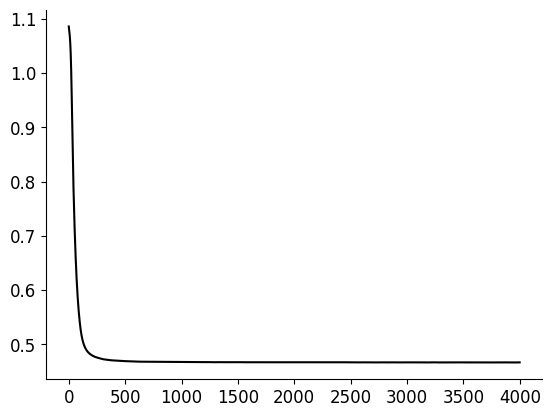

In [ ]:


model_20_NDNF_0x0_cue_raw = get_the_tca_model(fixed_residual_activity_dict_NDNF_newest, components=(0,20,0))


In [ ]:
model_20_NDNF_0x0_fixed_newest = model_20_NDNF_0x0_cue_raw
labels_cells_dict_all_K_NDNF_0x0_fixed_newest = get_labels_all_different_Ks_single(model_20_NDNF_0x0_fixed_newest, which_vectors=1)
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_fixed_newest, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")

activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint")


In [37]:
model_20_NDNF_raw_0x0 = model_and_mse_dict_NDNF[20]['model']

In [38]:
# labels_cells_dict_all_K_EC_x00_raw = get_labels_all_different_Ks_single(model_20_EC_raw_x00, which_vectors=0)
labels_cells_dict_all_K_NDNF_0x0_raw = get_labels_all_different_Ks_single(model_20_NDNF_raw_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_raw = get_labels_all_different_Ks_single(model_20_EC_raw_00x, which_vectors=2)

# labels_cells_dict_all_K_EC_x00_resid = get_labels_all_different_Ks_single(model_20_EC_resid_x00, which_vectors=0)
# labels_cells_dict_all_K_EC_0x0_resid = get_labels_all_different_Ks_single(model_20_EC_resid_0x0, which_vectors=1)
# labels_cells_dict_all_K_EC_00x_resid = get_labels_all_different_Ks_single(model_20_EC_resid_00x, which_vectors=2)

F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


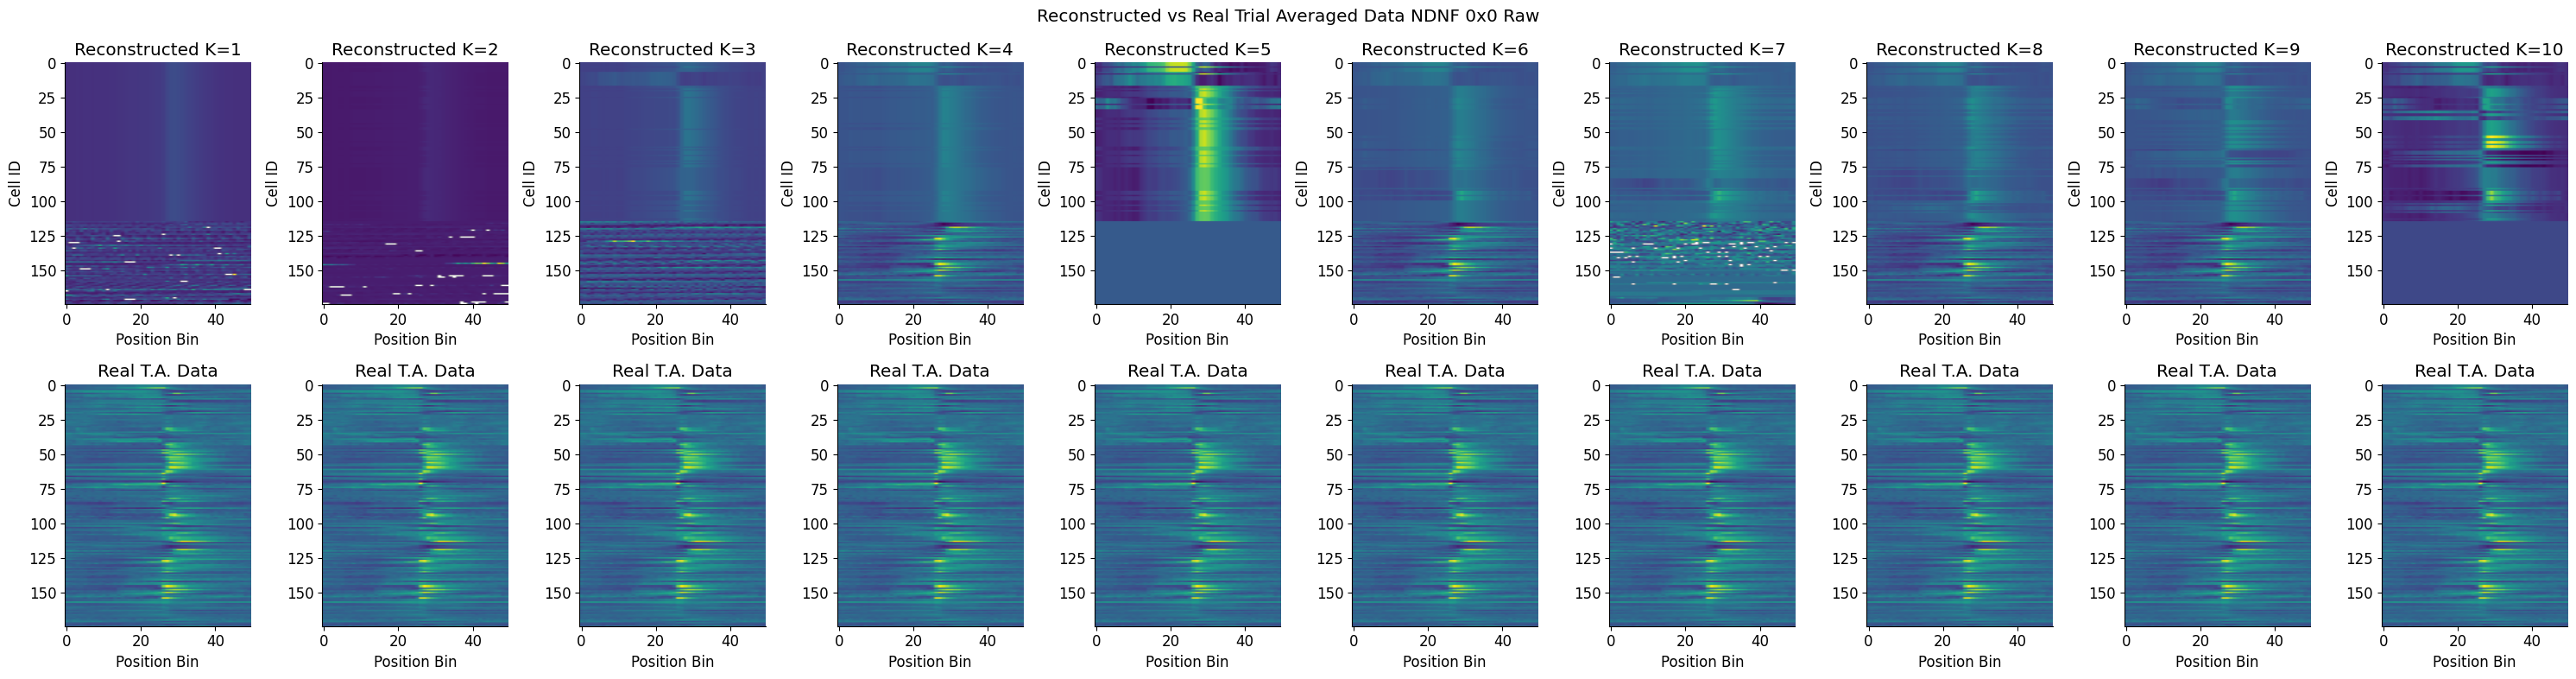

In [39]:
means_dict_cluster_0x0_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw, fixed_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Raw")


F.shape (20, 100, 50)  W.shape (20, 115)
X shape (mean over pos): (115, 20)


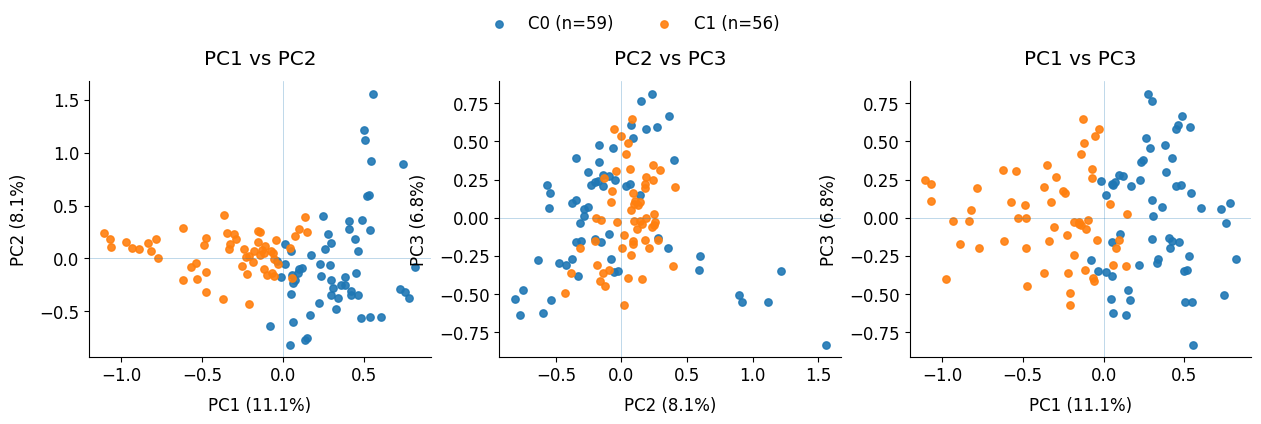

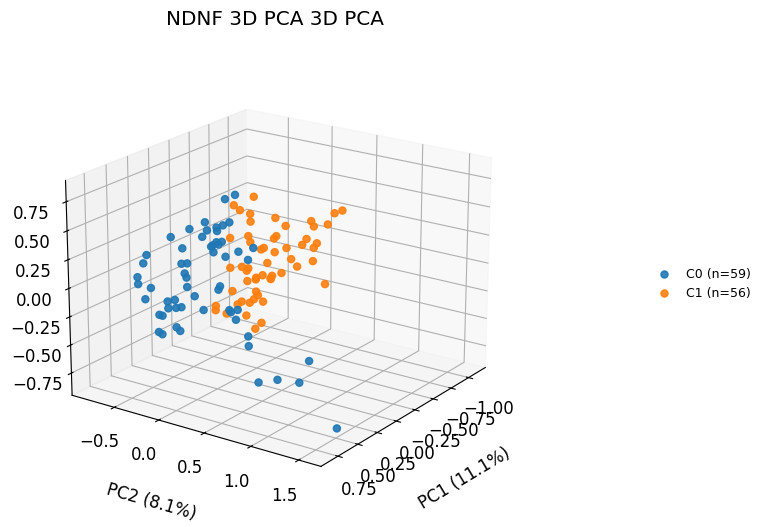

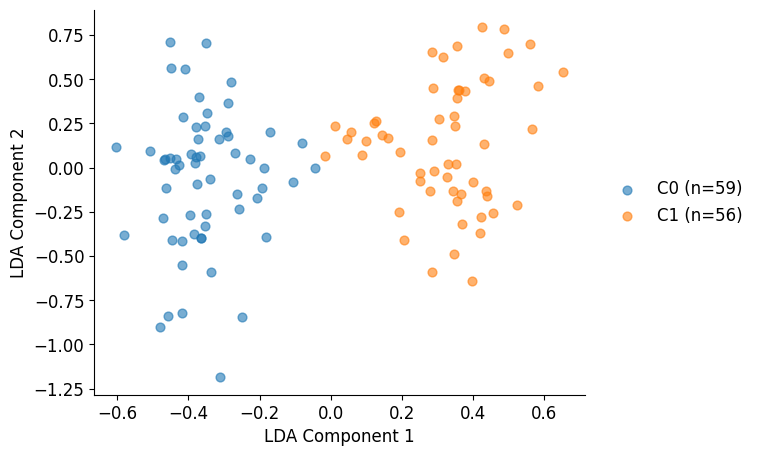

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10178 (\N{PERPENDICULAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


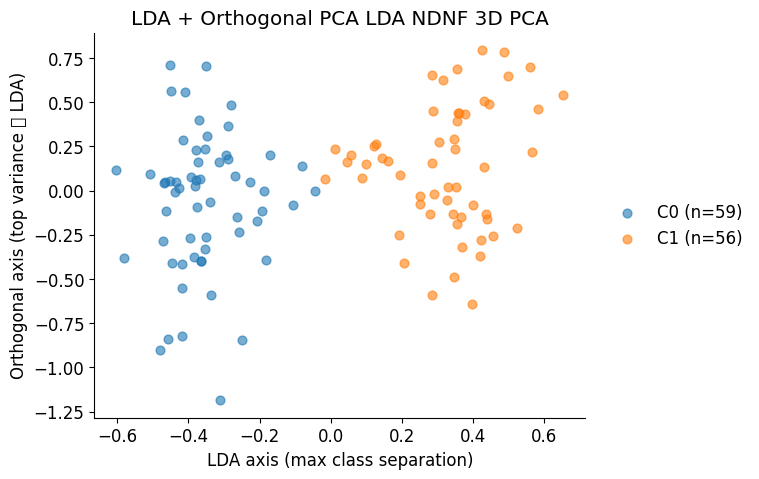

In [41]:
out = pca_cluster_viz(
    model_20_NDNF_raw_0x0,
    which_vectors=1,
    feature_space="loadings",     # or whatever you’re using in get_cell_features
    feature_mode="0x0",     # your existing arg
    n_cells_expected=115,         # fill with your expected count
    n_latents_expected=20,       # fill with your expected count
    n_components=3,
    num_clusters=2,               # <= set 2 if you want the LDA+orth trick; ≥3 uses LDA(2)
    title_prefix="NDNF 3D PCA")


In [42]:

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells'
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells'
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell'
cell_NDNF_model_ranks20_contig_x00_cue = get_model_data_per_cell(mse_dir)

    
fixed_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if 17<idx<31:
        fixed_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-18] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]

cued_cell_NDNF_model_ranks20_contig_x00_cue = {20: {}}
for idx, animal in enumerate(cell_NDNF_model_ranks20_contig_x00_cue[20]):
    if idx>30:
        cued_cell_NDNF_model_ranks20_contig_x00_cue[20][animal-31] = cell_NDNF_model_ranks20_contig_x00_cue[20][animal]


def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict

cued_cp_dict_NDNF = get_cp_dict(cued_cell_NDNF_model_ranks20_contig_x00_cue)

cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_cell_NDNF_model_ranks20_contig_x00_cue)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [43]:
activity_early_array, activity_array_late = get_activity_cut_learn(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_raw, activity_early_array, activity_array_late, K=2, title="Raw NDNF Clustered Changepoint")

# activity_early_array_resid, activity_array_late_resid = get_activity_cut_learn(residual_activity_dict_SST, cp_dict_NDNF)
# plot_clustered_data_learn(means_dict_cluster_0x0_resid, activity_early_array_resid, activity_array_late_resid, K=2, title="Residuals SST Clustered Changepoint 0x0")



KeyError: 7

In [19]:
cell_type_labels = labels_cells_dict_all_K_NDNF_0x0_raw[2]

cells_group_0 = np.where(cell_type_labels==0)[0]
cells_group_1 = np.where(cell_type_labels==1)[0]

print(cells_group_0)
print(cells_group_1)

[  3   7   8   9  10  11  12  13  14  15  16  19  21  22  23  24  30  34
  35  36  37  38  39  40  41  42  43  45  46  49  50  51  52  53  54  55
  56  58  59  60  64  65  66  68  69  70  71  72  74  75  93  94  95  97
  98  99 103 107 113]
[  0   1   2   4   5   6  17  18  20  25  26  27  28  29  31  32  33  44
  47  48  57  61  62  63  67  73  76  77  78  79  80  81  82  83  84  85
  86  87  88  89  90  91  92  96 100 101 102 104 105 106 108 109 110 111
 112 114]


In [21]:
# mse_dir = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell'
# testing_cell_SST_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

# mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell'
# testing_cell_EC_model_ranks20_reassign_regkmean_x00_cell = get_model_data_per_cell(mse_dir)

mse_dir ='/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell'
real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell = get_model_data_per_cell(mse_dir)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 8 cells
    Animal 22: 8 cells
    Animal 23: 9 cells
    Animal 24: 12 cells
    Animal 25: 13 cells
    Animal 26: 8 cells
    Animal 27: 9 cells
    Animal 28: 8 cells
    Animal 29: 8 cells
    Animal 30: 6 cells
    Animal 31: 11 cells
    Animal 32: 13 cells
    Animal 33: 19 cells
    Animal 34: 8 cells
    Animal 35: 12 cells
    Animal 36: 6 cells
    Animal 37: 9 cells
    Animal 38: 10 cells


In [25]:
trial_type_data = real_final_NDNF_model_ranks20_regkmean_reassign_x00_cell[20]

fixed_TT_data = {}
for idx, animal in enumerate(trial_type_data):
    if 17 < idx < 31:
        fixed_TT_data[f"animal_{idx+1}"] = trial_type_data[animal]


dict_keys(['animal_19', 'animal_20', 'animal_21', 'animal_22', 'animal_23', 'animal_24', 'animal_25', 'animal_26', 'animal_27', 'animal_28', 'animal_29', 'animal_30', 'animal_31'])

In [ ]:
def get_max_proportion(early_labels, use_max=True):
    unique_early_labels = np.unique(early_labels)
    if use_max:
        og_proportion=0
    else:
        og_proportion=1000
    good_dict=None
    for unique_label in unique_early_labels:
        amount = len(np.where(early_labels==unique_label)[0])
        len_early_labels = len(early_labels)
        proportion_early = amount / len_early_labels

        if use_max:
            if proportion_early > og_proportion:
                good_dict= {"unique_label":unique_label,
                        "fraction":proportion_early}
                og_proportion=proportion_early
        else:
            if proportion_early < og_proportion:
                good_dict= {"unique_label":unique_label,
                        "fraction":proportion_early}
                og_proportion=proportion_early
    return good_dict


In [246]:
def get_lists_out_of_dicts(fixed_TT_data, fixed_activity_dict_NDNF_newest, cp_dict_NDNF):
    TT_list = []
    for animal in fixed_TT_data:
        for cell in fixed_TT_data[animal]:
            TT_list.append(fixed_TT_data[animal][cell][1][f"cell_{cell}"])

    print(len(TT_list)) 

    NDNF_activity_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_activity_list.append(fixed_activity_dict_NDNF_newest[animal][cell])

    print(len(NDNF_activity_list)) 

    cp_list_NDNF = []

    for animal in cp_dict_NDNF:
        for cell in cp_dict_NDNF[animal]:
            cp_list_NDNF.append(cp_dict_NDNF[animal][cell])

    print(len(cp_list_NDNF)) 

    return TT_list, NDNF_activity_list, cp_list_NDNF

TT_list, NDNF_activity_list, cp_list_NDNF = get_lists_out_of_dicts(fixed_TT_data, fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF)


115
115
115


In [ ]:
# def get_elbow_score_data(new_cell_SST_model_ranks20_kmeans_reassign_x00, animal=0, cell=0):
#     MSE_dict = new_cell_SST_model_ranks20_kmeans_reassign_x00[20][animal][cell][1][f"cell_{cell}"]['MSE_dict']

#     MSE_list = []
#     for clusters_chosen in MSE_dict:
#         MSE_list.append(MSE_dict[clusters_chosen])
#     MSE_array = np.array(MSE_list)

#     elbow_kmeans = find_elbow_point(MSE_array)

#     return elbow_kmeans

def find_elbow_point(y_vals, min_index=2):
    from scipy.spatial.distance import cdist
    import numpy as np

    x = np.arange(len(y_vals))
    y = y_vals

    # First and last points
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # Compute distances to the line
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)

    vec_from_p1 = np.vstack((x - p1[0], y - p1[1])).T
    scalar_proj = np.dot(vec_from_p1, line_vec_norm)
    proj = np.outer(scalar_proj, line_vec_norm)
    dist_to_line = np.linalg.norm(vec_from_p1 - proj, axis=1)

    # Force elbow to be at least min_index (default = 2)
    elbow_idx = np.argmax(dist_to_line[min_index:]) + min_index
    return int(elbow_idx)



In [341]:
def get_most_expressed_cluster(TT_list, activity_list, cp_list_NDNF, early_late_none="early", to_include=None, most_expressed=True):
    
    if np.any(to_include) == None:
        indices_to_include = np.arange(115)
    else:
        indices_to_include = to_include

    most_expressed_label_dict = {}

    elbow_kmeans_array = np.empty(len(indices_to_include))

    for j, cell in enumerate(indices_to_include):
              
        activity_array = activity_list[cell]

        labels_example = TT_list[cell]["labels_dict"]["clusters_chosen_3"]

        MSE_dict = TT_list[cell]["MSE_dict"]

        MSE_array = np.empty(len(MSE_dict))

        for id, clusters_chosen in enumerate(MSE_dict):
            MSE = MSE_dict[clusters_chosen]
            MSE_array[id] = MSE
        
        elbow_kmeans = find_elbow_point(MSE_array)

        elbow_kmeans_array[j] = elbow_kmeans
        
        if early_late_none=='early':
            cp_early = cp_list_NDNF[cell][0]
            labels = labels_example[:cp_early]

        elif early_late_none=='late':
            cp_late = cp_list_NDNF[cell][1]
            labels = labels_example[cp_late:]

        elif early_late_none=='none':
            labels = labels_example
        else:
            raise ValueError("Invalid learning chunk")


        good_dict = get_max_proportion(labels, use_max=most_expressed)

        correct_indices = np.where(labels==good_dict["unique_label"])[0]
        activity_array_sliced = activity_array[:,correct_indices]


        most_expressed_label_dict[cell] = {"label":good_dict["unique_label"],
                                                        "cluster_activity": activity_array_sliced, "fraction":good_dict["fraction"]}

    return most_expressed_label_dict, elbow_kmeans_array
    
most_expressed=True

most_expressed_label_dict_animal_early, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", most_expressed=most_expressed)
most_expressed_label_dict_animal_late, elbow_kmeans_array = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", most_expressed=most_expressed)


most_expressed_label_dict_animal_early_group0, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", to_include=cells_group_0, most_expressed=most_expressed)
most_expressed_label_dict_animal_late_group0, elbow_kmeans_array_group0 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", to_include=cells_group_0, most_expressed=most_expressed)


most_expressed_label_dict_animal_early_group1, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="early", to_include=cells_group_1, most_expressed=most_expressed)
most_expressed_label_dict_animal_late_group1, elbow_kmeans_array_group1 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="late", to_include=cells_group_1, most_expressed=most_expressed)





def plot_no_learn_cell_types(most_expressed_label_dict_animal_cluster_0_all, most_expressed_label_dict_animal_cluster_1_all, elbow_kmeans_array, group=None, most_expressed=most_expressed):

    fig, axs = plt.subplots(4,2, figsize=(8,12))

    if most_expressed:
        fig.suptitle("Most Highly Expressed Cluster Per Cell")
    else:
        fig.suptitle("Least Highly Expressed Cluster Per Cell")

    fig.suptitle(group)

    mean_0_list = []
    mean_1_list = []

    mean_0_fractions_list = []
    mean_1_fractions_list = []

    for cell in most_expressed_label_dict_animal_cluster_0_all:
        array0 = most_expressed_label_dict_animal_cluster_0_all[cell]["cluster_activity"]
        mean0 = np.mean(array0, axis=1)
        mean_0_list.append(mean0)
        axs[0,0].plot(mean0)
        mean_0_fractions_list.append(most_expressed_label_dict_animal_cluster_0_all[cell]["fraction"])
    for cell in most_expressed_label_dict_animal_cluster_1_all:
        array1 = most_expressed_label_dict_animal_cluster_1_all[cell]["cluster_activity"]
        mean1 = np.mean(array1, axis=1)
        mean_1_list.append(mean1)
        axs[0,1].plot(mean1)
        mean_1_fractions_list.append(most_expressed_label_dict_animal_cluster_1_all[cell]["fraction"])



    axs[0,0].set_title("Group0")
    axs[0,1].set_title("Group1")

    mean_0_array = np.array(mean_0_list)
    mean_1_array = np.array(mean_1_list)

    mean_mean_0_array = np.mean(mean_0_array, axis=0)
    mean_mean_1_array = np.mean(mean_1_array, axis=0)

    sem_0_array = sem(mean_0_array, axis=0)
    sem_1_array = sem(mean_1_array, axis=0)

    axs[1,0].plot(mean_mean_0_array, label='Group0')
    axs[1,1].plot(mean_mean_1_array, label='Group1')
    axs[1,0].fill_between(range(len(mean_mean_0_array)), mean_mean_0_array-sem_0_array, mean_mean_0_array+sem_0_array, alpha=0.2)
    axs[1,1].fill_between(range(len(mean_mean_1_array)), mean_mean_1_array-sem_1_array, mean_mean_1_array+sem_1_array, alpha=0.2)

    axs[2,0].hist(mean_0_fractions_list)
    axs[2,0].set_xlabel("Fraction of Total Trials")
    axs[2,0].set_ylabel("Cells")

    axs[2,1].hist(mean_1_fractions_list)
    axs[2,1].set_xlabel("Fraction of Total Trials")
    axs[2,1].set_ylabel("Cells")

    axs[3,0].plot(mean_mean_0_array, label='Early')
    axs[3,0].plot(mean_mean_1_array, label='Late')
    axs[3,0].fill_between(range(len(mean_mean_0_array)), mean_mean_0_array-sem_0_array, mean_mean_0_array+sem_0_array, alpha=0.2)
    axs[3,0].fill_between(range(len(mean_mean_1_array)), mean_mean_1_array-sem_1_array, mean_mean_1_array+sem_1_array, alpha=0.2)
    axs[3,0].set_title(group)
    axs[3,0].legend()

    axs[3,1].hist(elbow_kmeans_array)
    axs[3,1].set_title("Elbow Num Clusters Distribution")
    axs[3,1].set_xlabel("Num Clusters")
    axs[3,1].set_xlabel("Num Cells")
        
    plt.tight_layout()
    plt.show()


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

def plot_early_late_activity(
    most_expressed_label_dict_animal_early,
    most_expressed_label_dict_animal_late,
    elbow_kmeans_array,
    group=None,
    most_expressed=True
):
    # ---------- compute means/sems once ----------
    mean_early_list = []
    mean_late_list  = []

    for cell in most_expressed_label_dict_animal_early:
        early_array = most_expressed_label_dict_animal_early[cell]["cluster_activity"]  # (clusters, time) or similar
        late_array  = most_expressed_label_dict_animal_late[cell]["cluster_activity"]

        mean_early = np.mean(early_array, axis=1)  # per-cluster mean trace (adjust if your axis differs)
        mean_late  = np.mean(late_array,  axis=1)

        mean_early_list.append(mean_early)
        mean_late_list.append(mean_late)

    mean_early_array = np.asarray(mean_early_list)
    mean_late_array  = np.asarray(mean_late_list)

    mean_mean_early_array = np.mean(mean_early_array, axis=0)
    mean_mean_late_array  = np.mean(mean_late_array,  axis=0)

    sem_early_array = sem(mean_early_array, axis=0, nan_policy='omit')
    sem_late_array  = sem(mean_late_array,  axis=0, nan_policy='omit')

    # ---------- figure with nested grids ----------
    fig = plt.figure(figsize=(18, 6), constrained_layout=True)
    title_txt = "Most Highly Expressed Cluster Per Cell" if most_expressed else "Most Highly Expressed Cluster Per Cell"
    if group:
        fig.suptitle(f"{title_txt} — {group}", y=1.05)
    else:
        fig.suptitle(title_txt, y=1.05)

    # Outer grid: 2 rows × 4 cols; first column is wide to host a 2×2 sub-grid
    outer = fig.add_gridspec(2, 4, width_ratios=[1.3, 1.0, 1.0, 1.0], wspace=0.1, hspace=0.01)

    # ----- Left block: 2×2 subgrid (your original first figure) -----
    left = outer[:, 0].subgridspec(2, 2, wspace=0.01, hspace=0.1, height_ratios=(1.0,1.0), width_ratios=(0.1,0.1))
    ax00 = fig.add_subplot(left[0, 0])
    ax01 = fig.add_subplot(left[0, 1])
    ax10 = fig.add_subplot(left[1, 0])
    ax11 = fig.add_subplot(left[1, 1])

    # Top row: per-cell traces (Early / Late)
    for cell in most_expressed_label_dict_animal_early:
        early_array = most_expressed_label_dict_animal_early[cell]["cluster_activity"]
        late_array  = most_expressed_label_dict_animal_late[cell]["cluster_activity"]
        ax00.plot(np.mean(early_array, axis=1))
        ax01.plot(np.mean(late_array,  axis=1))

    ax00.set_title("Early")
    ax01.set_title("Late")

    # Bottom row: mean ± SEM
    tE = np.arange(len(mean_mean_early_array))
    tL = np.arange(len(mean_mean_late_array))
    ax10.plot(mean_mean_early_array, label='Early')
    ax11.plot(mean_mean_late_array,  label='Late')

    ax10.fill_between(tE, mean_mean_early_array - sem_early_array,
                           mean_mean_early_array + sem_early_array, alpha=0.2)
    ax11.fill_between(tL, mean_mean_late_array  - sem_late_array,
                           mean_mean_late_array  + sem_late_array,  alpha=0.2)

    ax10.legend(loc='upper right', frameon=False)
    ax11.legend(loc='upper right', frameon=False)

    # ----- Right three single panels (formerly 1×3) -----
    axA = fig.add_subplot(outer[:, 1])  # summary line plot
    axB = fig.add_subplot(outer[:, 2])  # proportions (your eval_proportion)
    axC = fig.add_subplot(outer[:, 3])  # histogram

    # Summary mean ± SEM overlay
    axA.plot(mean_mean_early_array, label='Early')
    axA.plot(mean_mean_late_array,  label='Late')
    axA.fill_between(tE, mean_mean_early_array - sem_early_array,
                          mean_mean_early_array + sem_early_array, alpha=0.2)
    axA.fill_between(tL, mean_mean_late_array  - sem_late_array,
                          mean_mean_late_array  + sem_late_array,  alpha=0.2)
    if group:
        axA.set_title(group)
    axA.legend(frameon=False)

    # Proportions panel (reuse your existing helper)
    # Make sure eval_proportion accepts an axes handle.
    eval_proportion(most_expressed_label_dict_animal_early,
                    most_expressed_label_dict_animal_late,
                    group="All Cells", ax=axB)

    # Histogram
    axC.hist(elbow_kmeans_array, bins='auto')
    axC.set_title("Early Elbow Num Clusters Distribution")
    axC.set_xlabel("Number of Clusters")
    axC.set_ylabel("Number of Cells")

    plt.show()

    



In [342]:
for cell in most_expressed_label_dict_animal_all_group0:
    print(most_expressed_label_dict_animal_all_group0[cell]["fraction"])

0.37383177570093457
0.7564102564102564
0.49230769230769234
0.48717948717948717
0.5230769230769231
0.5230769230769231
0.4948717948717949
0.48205128205128206
0.6846153846153846
0.5794871794871795
0.4230769230769231
0.5
0.6046511627906976
0.6395348837209303
0.37790697674418605
0.45930232558139533
0.41358024691358025
0.4051724137931034
0.7672413793103449
0.6810344827586207
0.45689655172413796
0.3448275862068966
0.4482758620689655
0.6724137931034483
0.3448275862068966
0.7444444444444445
0.7055555555555556
0.4166666666666667
0.5722222222222222
0.4666666666666667
0.5055555555555555
0.5327868852459017
0.36885245901639346
0.6557377049180327
0.7377049180327869
0.39344262295081966
0.39344262295081966
0.7213114754098361
0.3442622950819672
0.38524590163934425
0.5625
0.3828125
0.3984375
0.7890625
0.640625
0.40625
0.4375
0.40625
0.609375
0.5
0.410958904109589
0.8356164383561644
0.952054794520548
0.863013698630137
0.5205479452054794
0.5205479452054794
0.41025641025641024
0.5282051282051282
0.61


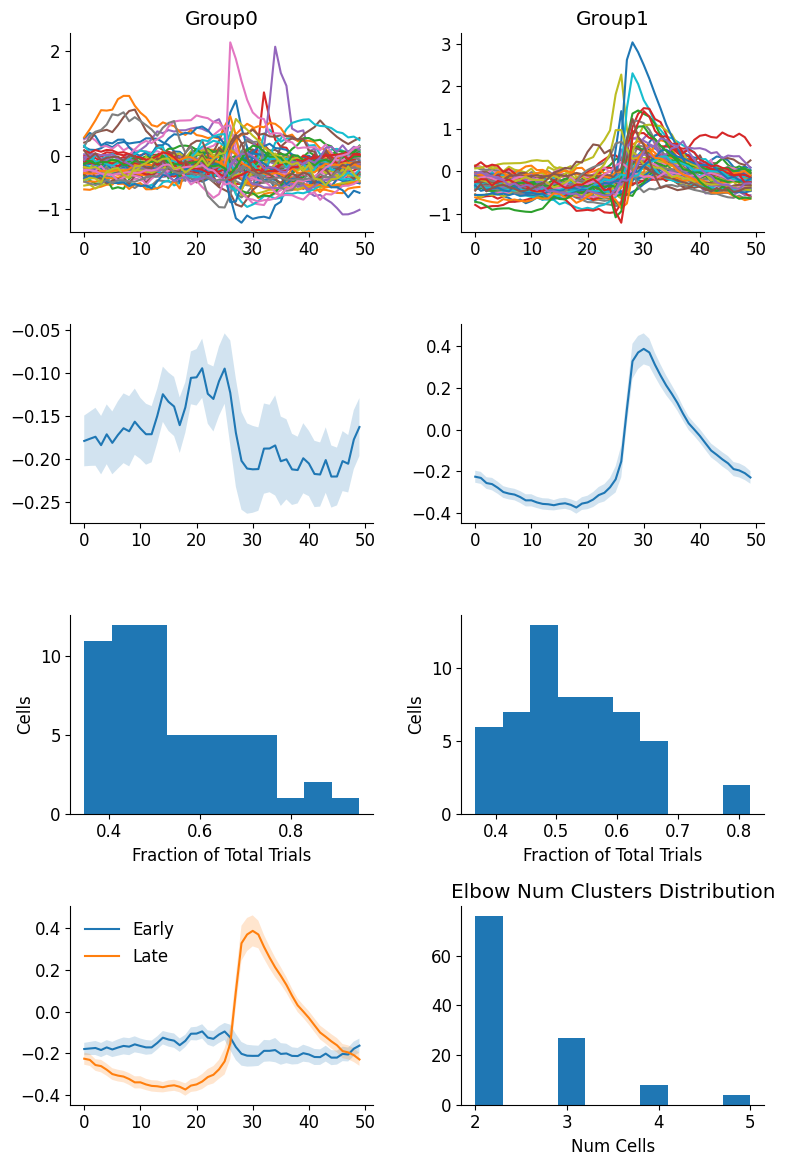

In [343]:


most_expressed_label_dict_animal_all_group0, _ = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="none", to_include=cells_group_0, most_expressed=most_expressed)
most_expressed_label_dict_animal_all_group1, elbow_kmeans_array_group1 = get_most_expressed_cluster(TT_list, NDNF_activity_list, cp_list_NDNF, early_late_none="none", to_include=cells_group_1, most_expressed=most_expressed)

plot_no_learn_cell_types(most_expressed_label_dict_animal_all_group0, most_expressed_label_dict_animal_all_group1, elbow_kmeans_array, group=None, most_expressed=most_expressed)


In [344]:
from scipy.stats import ttest_rel

def eval_proportion(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, group=None, ax=None):
    early_vals = []
    late_vals  = []

    for cell in most_expressed_label_dict_animal_early:
        early_vals.append(most_expressed_label_dict_animal_early[cell]["fraction"])
        late_vals.append(most_expressed_label_dict_animal_late[cell]["fraction"])

    early_vals = np.array(early_vals)
    late_vals  = np.array(late_vals)

    # paired t test
    t,p = ttest_rel(early_vals, late_vals)

    # plot all individual paired points
    for e,l in zip(early_vals, late_vals):
        ax.plot([0,1], [e,l], color='gray', alpha=0.4)
        ax.plot(0, e, 'o', color='black')
        ax.plot(1, l, 'o', color='black')

    # plot means
    ax.plot([0,1], [early_vals.mean(), late_vals.mean()],
            color='red', marker='o', linewidth=2)

    ax.set_xticks([0,1])
    ax.set_xticklabels(['Early','Late'])
    ax.set_ylabel("Fraction of Trials in Learning Block")
    ax.set_title(f"{group} Paired t-test (p = {p:.3f})")

   

# eval_proportion(most_expressed_label_dict_animal_early, most_expressed_label_dict_animal_late, group="All Cells")
# eval_proportion(most_expressed_label_dict_animal_early_group1, most_expressed_label_dict_animal_late_group1, "Cell Type 1")
# eval_proportion(most_expressed_label_dict_animal_early_group0, most_expressed_label_dict_animal_late_group0, "Cell Type 0")


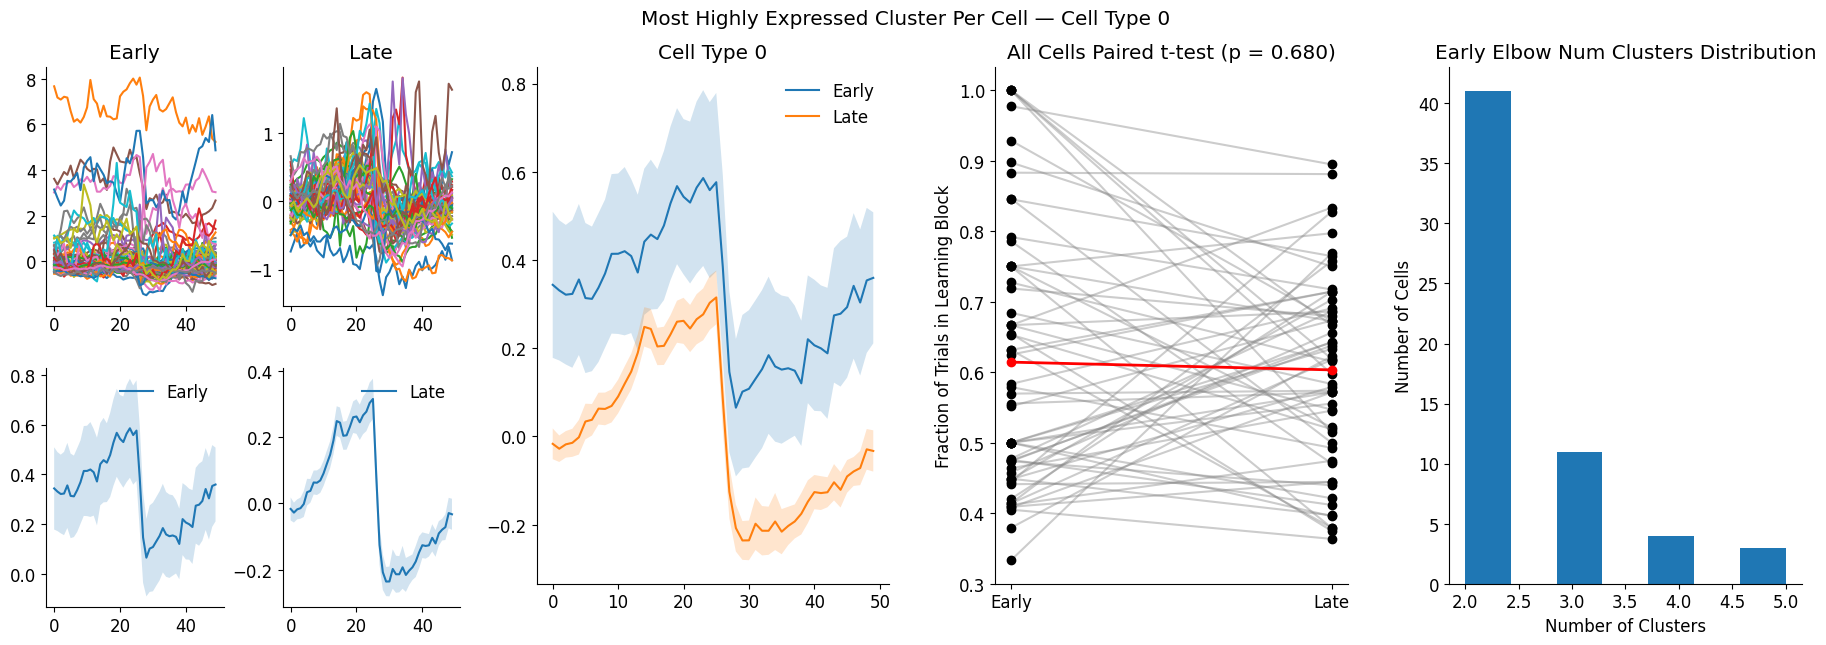

In [345]:

plot_early_late_activity(most_expressed_label_dict_animal_early_group0, most_expressed_label_dict_animal_late_group0, elbow_kmeans_array_group0, group="Cell Type 0")




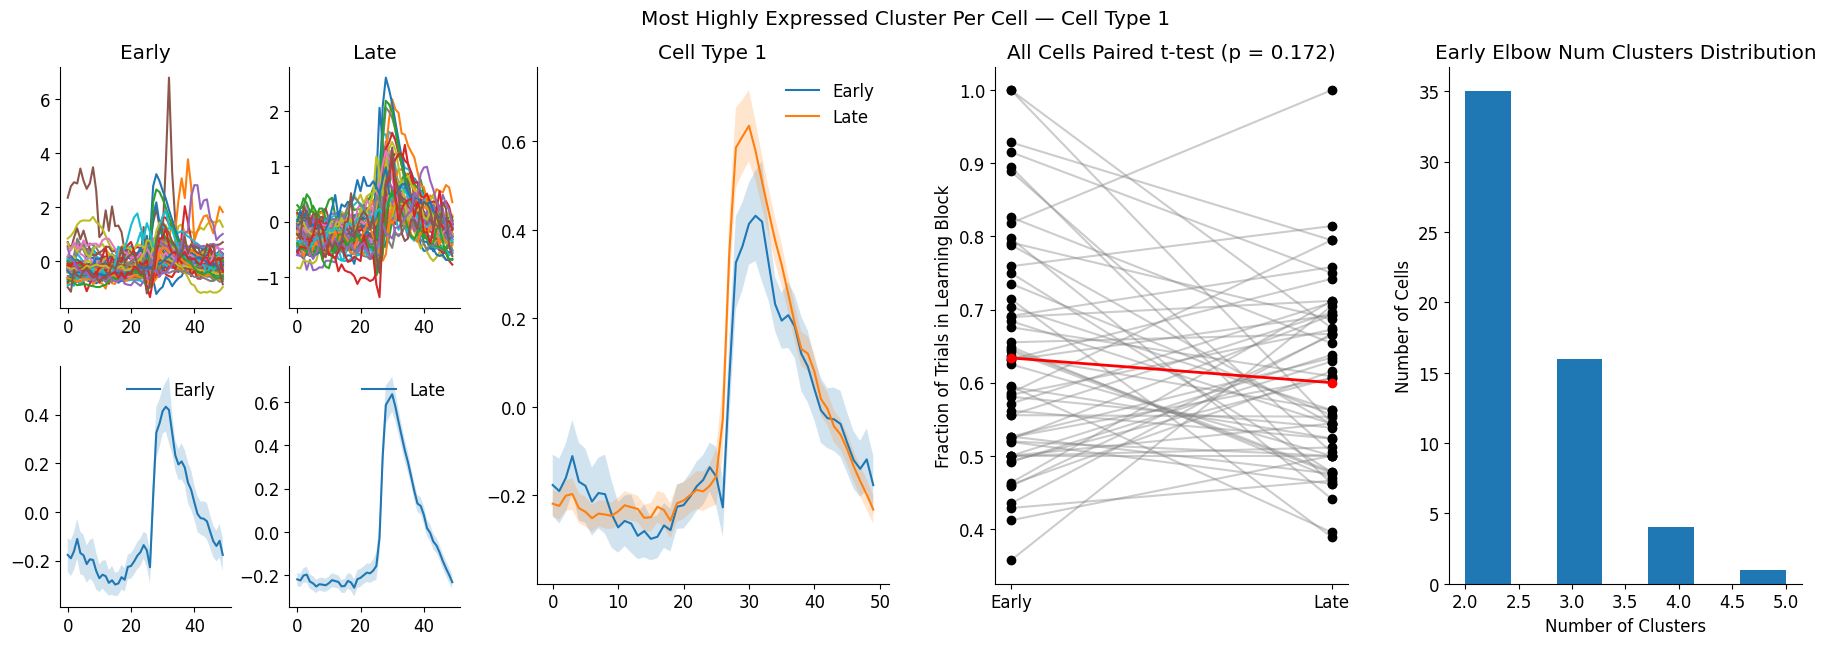

In [346]:

plot_early_late_activity(most_expressed_label_dict_animal_early_group1, most_expressed_label_dict_animal_late_group1, elbow_kmeans_array_group1, group="Cell Type 1")


In [3]:

def plot_mean_resid(residual_activity_dict_NDNF_newest, title):
    cue_residual_activity_dict_NDNF_newest = {}
    for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
        if idx > 30:
            cue_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

    listy = []
    for animal in cue_residual_activity_dict_NDNF_newest:
        print(animal)
        for cell in cue_residual_activity_dict_NDNF_newest[animal]:
            listy.append(np.mean(cue_residual_activity_dict_NDNF_newest[animal][cell], axis=1))

    good_array = np.array(listy)
    means = np.mean(good_array, axis=0)
    sems = sem(good_array, axis=0)
    plt.plot(means)
    plt.axvline(10, linestyle="--", color='red', label='Cue')
    plt.fill_between(range(len(means)), means+sems, means-sems, alpha=0.2)
    plt.legend()
    plt.title(title)

    return cue_residual_activity_dict_NDNF_newest


animal_32
animal_33
animal_34
animal_35
animal_36
animal_37
animal_38
animal_39


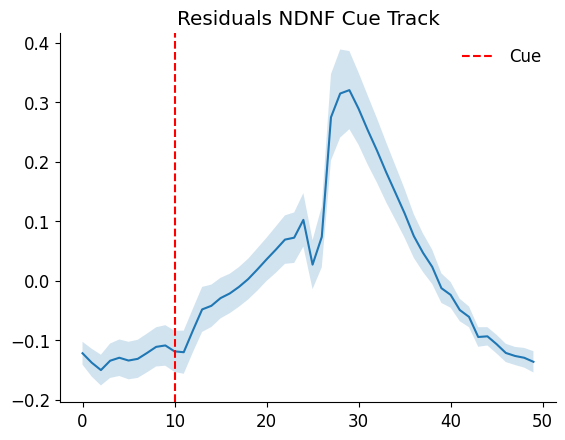

In [4]:
cue_residual_activity_dict_NDNF_newest = plot_mean_resid(residual_activity_dict_NDNF_newest, title="Residuals NDNF Cue Track")

animal_32
animal_33
animal_34
animal_35
animal_36
animal_37
animal_38
animal_39


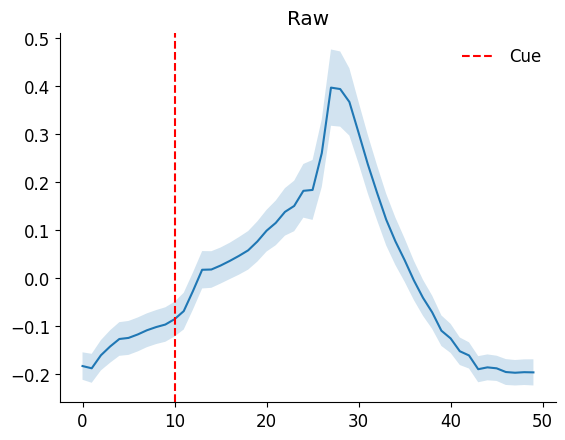

In [386]:
cue_activity_dict_NDNF_newest = plot_mean_resid(activity_dict_NDNF_newest, title="Raw")

Loss: 0.3833028336026618 : 100%|██████████| 4000/4000 [02:49<00:00, 23.57it/s] 


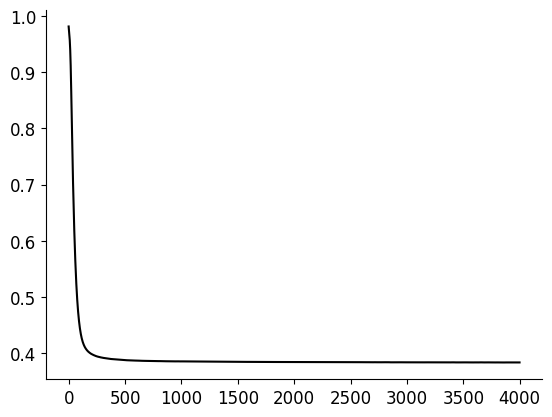

In [369]:
model_20_NDNF_resid_0x0_cue = get_the_tca_model(cue_residual_activity_dict_NDNF_newest, components=(0,20,0))


In [398]:
save_path="/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/model_20_NDNF_resid_0x0_cue.pkl"

with open (save_path, 'wb') as f:
    pickle.dump(model_20_NDNF_resid_0x0_cue, f)

Loss: 0.3812292083868302 : 100%|██████████| 4000/4000 [02:19<00:00, 28.63it/s] 


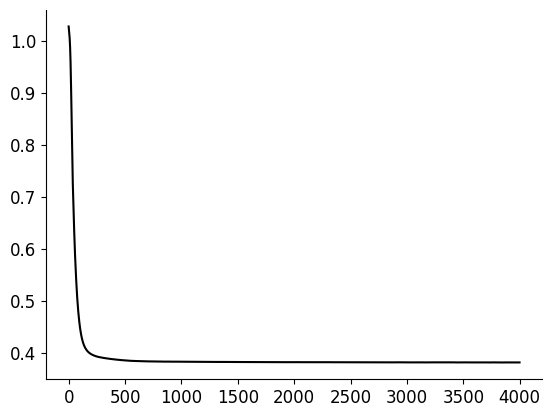

In [388]:
model_20_NDNF_0x0_cue_raw = get_the_tca_model(cue_activity_dict_NDNF_newest, components=(0,20,0))


In [370]:
labels_cells_dict_all_K_NDNF_0x0_resid_cue = get_labels_all_different_Ks_single(model_20_NDNF_resid_0x0_cue, which_vectors=1)


F.shape (20, 123, 50)  W.shape (20, 88)
X shape (mean over pos): (88, 20)


In [389]:
labels_cells_dict_all_K_NDNF_0x0_raw_cue = get_labels_all_different_Ks_single(model_20_NDNF_0x0_cue_raw, which_vectors=1)


F.shape (20, 123, 50)  W.shape (20, 88)
X shape (mean over pos): (88, 20)


In [1]:
labels_cells_dict_all_K_NDNF_0x0_raw_cue

NameError: name 'labels_cells_dict_all_K_NDNF_0x0_raw_cue' is not defined

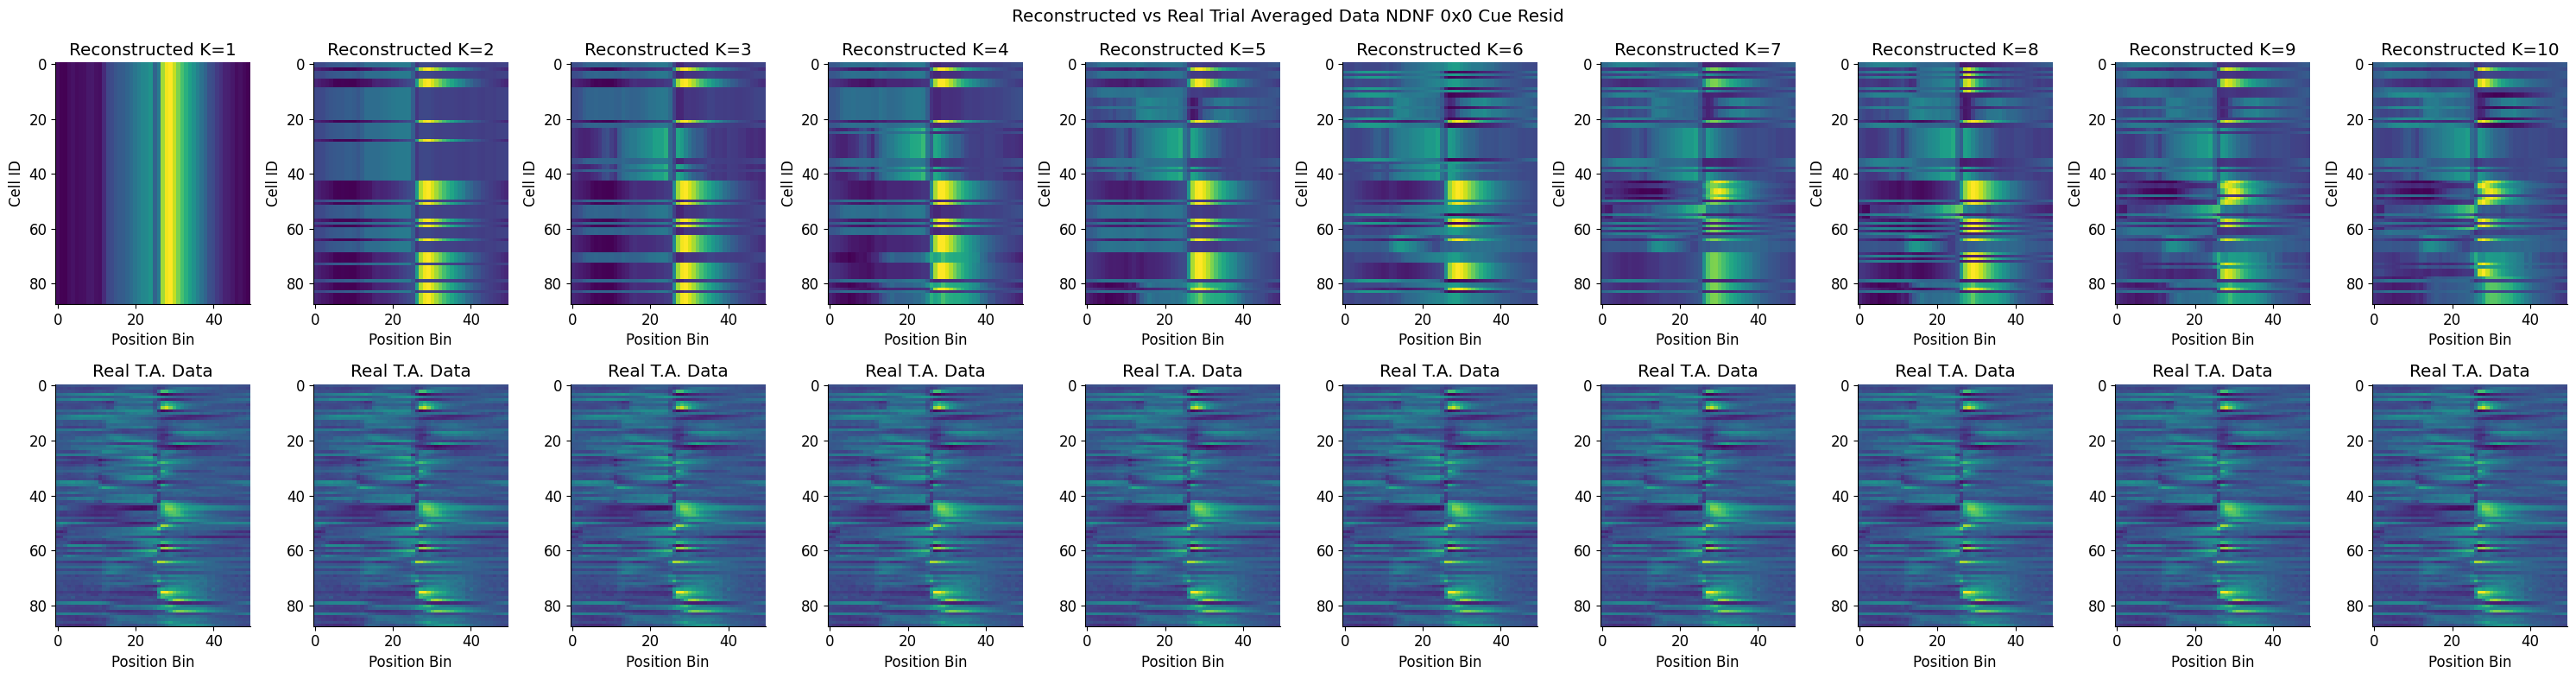

In [373]:
means_dict_cluster_0x0_cue_resid = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_resid_cue, cue_residual_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Cue Resid")

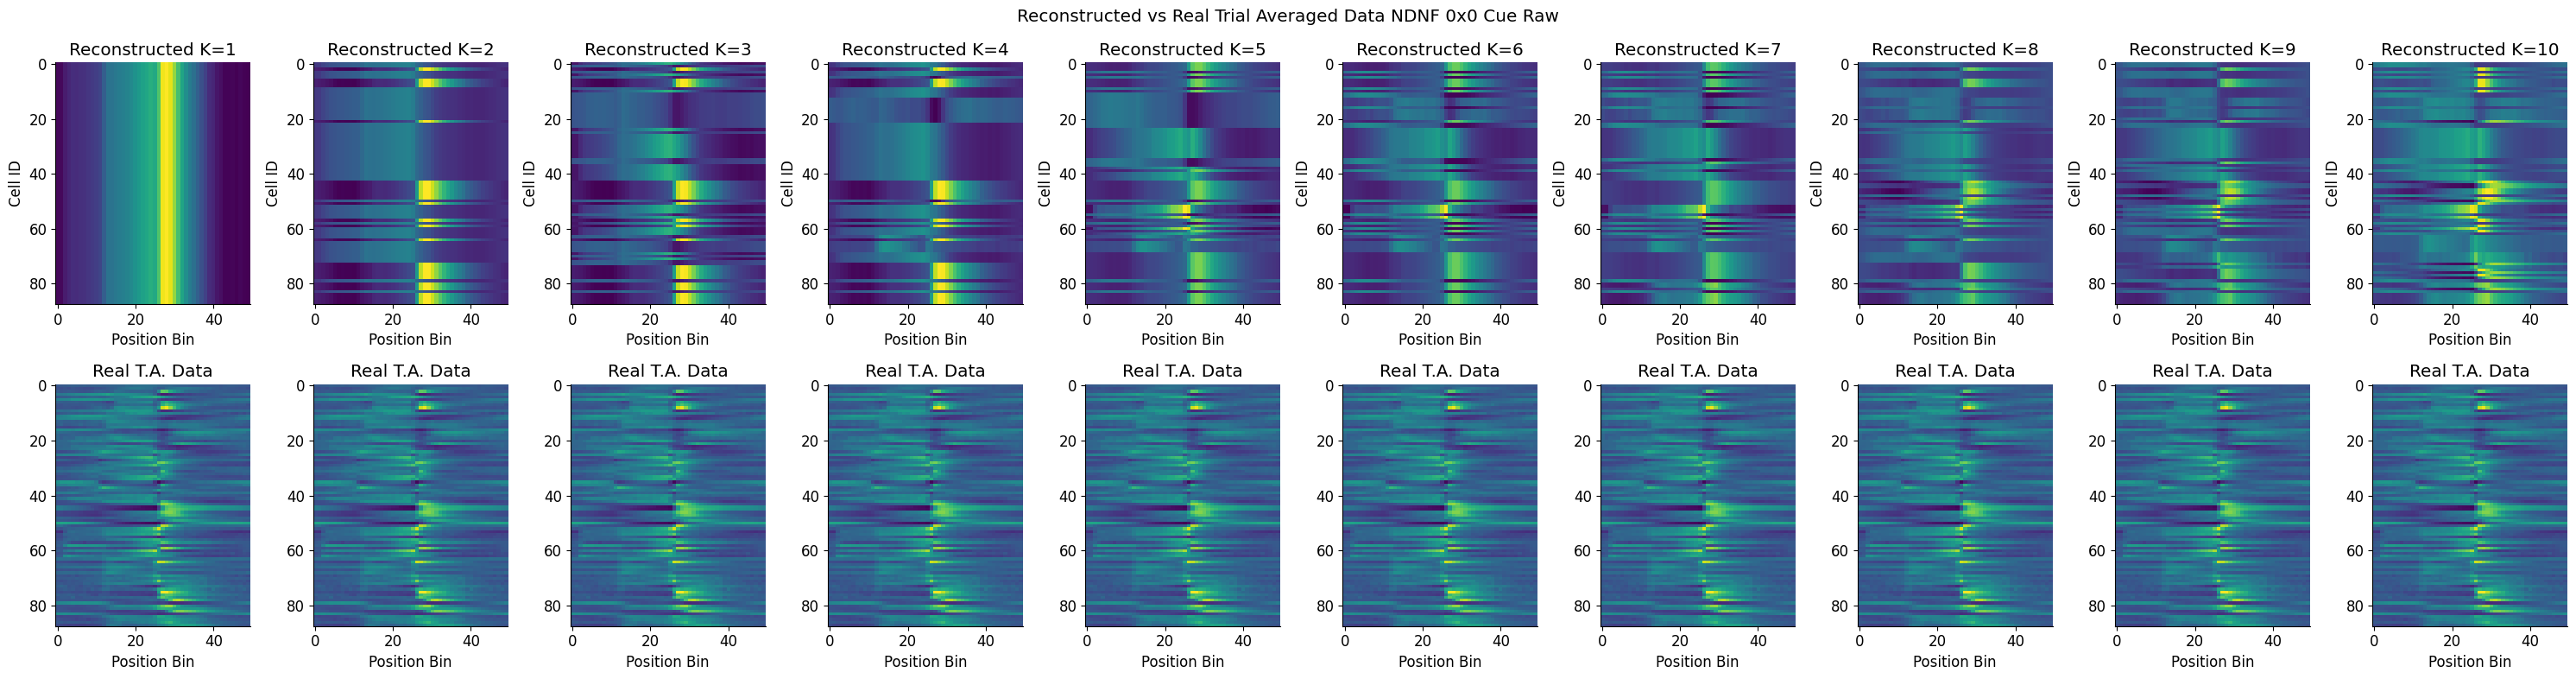

In [390]:
means_dict_cluster_0x0_cue_raw = plot_reconstructions(labels_cells_dict_all_K_NDNF_0x0_raw_cue, cue_activity_dict_NDNF_newest, r_dict_vel, r_dict_licks, prefix="NDNF 0x0 Cue Raw")

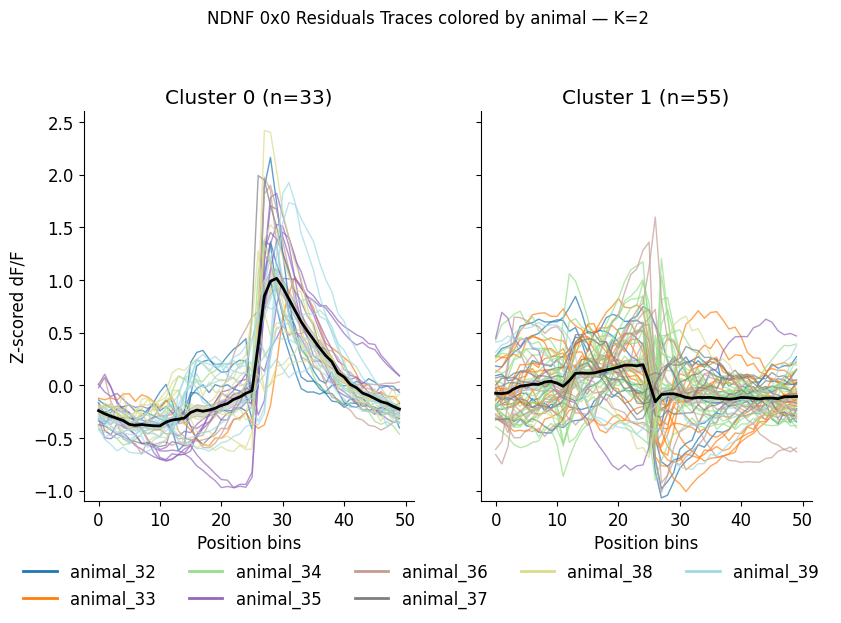

In [ ]:
from comparing_slice_TCA_methods import get_cells_per_animal_dict
cells_per_animal_dict = get_cells_per_animal_dict(cue_residual_activity_dict_NDNF_newest)
plot_cluster_traces_by_animal(means_dict_cluster_0x0_cue_resid,
                              cue_residual_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=2,
                              ncol=5, spacing=0.2,
                              title_prefix="NDNF Cue Track 0x0 Residuals")

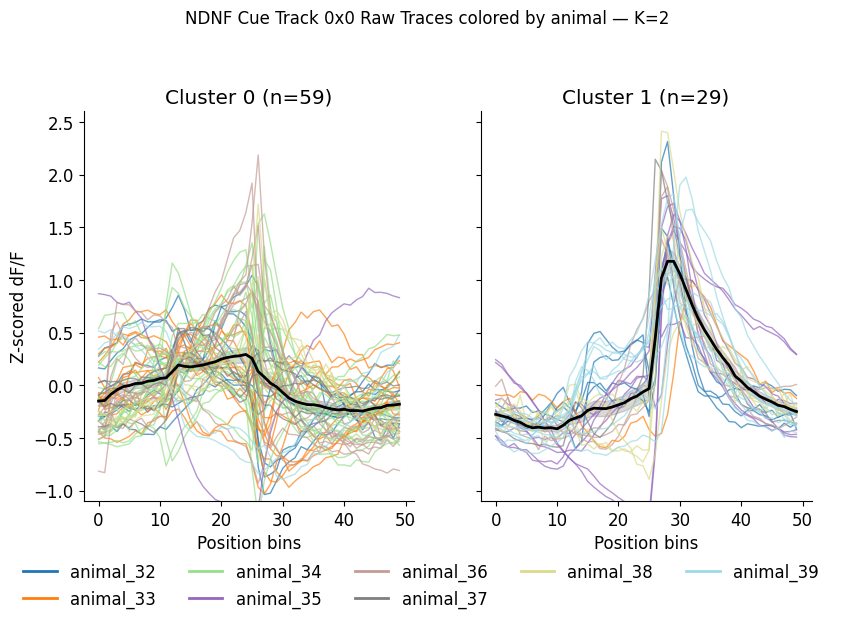

In [393]:
from comparing_slice_TCA_methods import get_cells_per_animal_dict
cells_per_animal_dict = get_cells_per_animal_dict(cue_activity_dict_NDNF_newest)
plot_cluster_traces_by_animal(means_dict_cluster_0x0_cue_raw,
                              cue_activity_dict_NDNF_newest,
                              cells_per_animal_dict,
                              K=2,
                              ncol=5, spacing=0.2,
                              title_prefix="NDNF Cue Track 0x0 Raw")

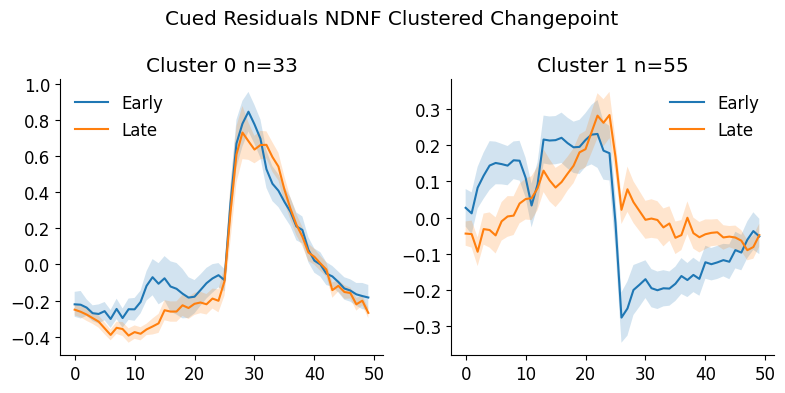

In [395]:
#### using the cued track 
activity_early_array, activity_array_late = get_activity_cut_learn(cue_residual_activity_dict_NDNF_newest, cued_cp_dict_NDNF)
plot_clustered_data_learn(means_dict_cluster_0x0_cue_resid, activity_early_array, activity_array_late, K=2, title="Cued Track Residuals NDNF Clustered Changepoint")

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_animal_composition_stacked(means_dict_cluster, cells_per_animal_dict, K,
                                            title_prefix="", show_percent_labels=False):
    # --- build cell_id -> animal map ---
    cell_to_animal = {}
    for animal, cell_ids in cells_per_animal_dict.items():
        for cid in cell_ids:
            cell_to_animal[int(cid)] = animal

    # --- cluster membership dict for this K ---
    clust_idx_dict = means_dict_cluster[K]["cell_ids_per_cluster_dict"]  # {cluster_label: array(cell_ids)}
    clusters = sorted(clust_idx_dict.keys())  # keep order stable

    # --- all animals & consistent colors ---
    animals = sorted(set(cell_to_animal.values()))
    cmap = plt.get_cmap("tab20", len(animals))
    animal_to_color = {a: cmap(i) for i, a in enumerate(animals)}

    # --- counts matrix: rows=clusters, cols=animals ---
    counts = np.zeros((len(clusters), len(animals)), dtype=int)
    for r, clab in enumerate(clusters):
        for cid in clust_idx_dict[clab]:
            a = cell_to_animal.get(int(cid), None)
            if a is not None:
                c = animals.index(a)
                counts[r, c] += 1

    totals = counts.sum(axis=1)  # cells per cluster

    # --- plot stacked bars (height = counts, stacked by animal) ---
    x = np.arange(len(clusters))
    fig, ax = plt.subplots(figsize=(1.2*len(clusters)+3, 5))
    bottom = np.zeros_like(totals, dtype=float)

    bars = []
    for j, a in enumerate(animals):
        b = ax.bar(x, counts[:, j], bottom=bottom, width=0.8,
                   color=animal_to_color[a], label=f"{a}")
        bars.append(b)
        bottom += counts[:, j]

    # x-ticks as cluster labels with n
    ax.set_xticks(x, [f"C{clab}\n(n={totals[i]})" for i, clab in enumerate(clusters)])
    ax.set_ylabel("# cells")
    ax.set_title(f"{title_prefix} K={K}")

    # optional % labels inside segments
    if show_percent_labels:
        with np.errstate(divide='ignore', invalid='ignore'):
            props = counts / totals[:, None]
            props[np.isnan(props)] = 0.0
        for i in range(len(clusters)):
            cum = 0.0
            for j in range(len(animals)):
                h = counts[i, j]
                if h > 0 and props[i, j] >= 0.07:  # only label if ≥7% to avoid clutter
                    ax.text(x[i], cum + h/2.0, f"{props[i, j]*100:.0f}%",
                            ha="center", va="center", fontsize=8, color="white")
                cum += h

    # legend outside
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.subplots_adjust(right=0.78)
    plt.tight_layout()
    plt.show()

# Example call:
plot_cluster_animal_composition_stacked(means_dict_cluster_0x0_cue_resid, cells_per_animal_dict, K=2,
                                        title_prefix="NDNF 0x0 Residual Cue", show_percent_labels=True)


NameError: name 'means_dict_cluster_0x0_cue_resid' is not defined

In [ ]:

cells_group_0 = np.where(cell_type_labels==0)[0]
cells_group_1 = np.where(cell_type_labels==1)[0]

print(cells_group_0)

In [ ]:
data_list = []
for animal in cue_residual_activity_dict_NDNF_newest:
    for cell in cue_residual_activity_dict_NDNF_newest[animal]:
